In [ ]:
!pip install -q --upgrade pip
!pip uninstall -y numpy scipy pandas scanpy anndata >/dev/null 2>&1 || true
!pip install numpy==1.26.4 scipy==1.11.4 pandas==2.2.2 scanpy==1.10.2 anndata==0.10.8
import os; os._exit(0)  # Restart runtime after first execution


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 176.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 194.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 177.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 78.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [scanpy]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
libpysal 4.14.1 requires scipy>=1.12.0, but you have scipy 1.11.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
esda 2.9.0 requires scipy>=1.12, but you have scipy 1.11.4 which is incompatible.
cupy-cuda

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scanpy version: {sc.__version__}")
print(f"Anndata version: {ad.__version__}")

print("Libraries successfully imported and versions displayed!")

NumPy version: 1.26.4
Pandas version: 2.2.2
Scanpy version: 1.10.2
Anndata version: 0.10.8
Libraries successfully imported and versions displayed!


# Celcomen on matched PDAC spatial transcriptomics: experiments and validation

This notebook pulls together the Celcomen work on the matched primary and metastasis PDAC sections
(T11 and HM11). I split it into three parts so it reads top to bottom the way I actually worked through
it. First the setup, where I load the data and train the three couplings. Then the experiments, where I
use the trained sparse signed model to perturb fibrotic niches in silico and read the effect on the
tumour compartment. Last, the validation checks, where I stress test every design choice against a null
so each claim in the experiments has something backing it up.

Each method gets its own labelled section, so this can be read as a methods log rather than a scratchpad.
As objects get built I print their shapes to the output and say them in the text too, so it's always
clear what's flowing through each step. The expression matrix has shape number of spots by number of
genes. The learned coupling W has shape number of genes by number of genes. A baseline relaxation has the
same shape as the expression matrix, one relaxed profile per spot.

I kept the two companion notebooks separate on purpose. The alternative model families — the
attention-based GAT, the constrained GGAT, the niche-aware Matern readout — live in a methodology
notebook. The causal discovery layer, which turns the signed coupling into an oriented and
de-confounded graph, has its own causality notebook. This one stays focused on the core Celcomen model
and the evidence behind it.

# Results: signed stroma to tumour coupling in matched PDAC sections

I learned a signed gene-by-gene coupling with Celcomen on two matched pancreatic ductal adenocarcinoma
sections — the primary T11 and the metastasis HM11 — and read it by perturbing the fibrotic program in
silico and measuring the change in the tumour compartment. I ran the same analysis on both sections, and
what comes back is consistent and, I think, honest. The model and its mechanics hold up, the direction of
the effect is clear, and the biological ranking reproduces, while the statistical significance of the
cross block and its spatial locality are not established at this resolution. Those two things sit
together rather than contradicting each other, and keeping them separate is what makes the result worth
trusting.

The machinery does what it should. The spherical normalization is essentially lossless, with a round trip
correlation of 0.9985, so the coupling is learned on faithful expression rather than a distorted version
of it. A knockout genuinely registers at its source — driver expression falls from 0.1262 to 0.0144 after
relaxation. And on a synthetic ground truth the model recovers the sign of the coupling well above chance,
with an agreement of 0.88, a rank correlation of 0.81, and a binomial p-value below 0.0001. These three
results tell me the pipeline reconstructs, perturbs, and signs the coupling correctly, so anything read
from it afterwards rests on a reliable base.

On top of that, two biological findings feel strong enough to state plainly. The first is directionality.
When I perturb the fibrotic drivers and read the tumour, then do the symmetric experiment the other way,
the stroma-to-tumour influence is far larger than the reverse — by about a factor of three in the
metastasis and about thirty times per driver in the primary. This asymmetry is the observational
signature that the stroma sits upstream of the tumour program rather than the other way around, and it's
the single most defensible statement this analysis supports. The second is specificity and cooperation.
The real fibrotic niche suppresses the tumour far more than a random set of genes of the same size — by
roughly seventeen times in the metastasis and nine times in the primary — and when the strongest niches
are removed together their joint effect consistently beats the sum of their single effects, across every
seed and both sections, which says the niches cooperate rather than acting alone. The suppression itself
holds its direction across every random seed I tested.

Here's the honest part — where the evidence stops. The signed fibrotic-to-tumour cross block is
consistently negative, which is the direction I'd expect if the stroma suppresses the tumour, but it
doesn't separate from a permutation null on either section. In the metastasis the permutation p-value is
0.30 and in the primary it's 0.58, and the intra-versus-inter block test tells the same story — cross
block negative, but not distinguishable from random gene partitions. The effect isn't spatially local
either. Binning the knockout influence by distance from the perturbed niche, it stays essentially flat
past the first hop, and a control that keeps the model but shuffles the spatial graph reproduces almost
the entire effect — so what I'm seeing behaves like a tissue-wide, mean-field coupling rather than a
sharp interface signal. The random niche control also turned out to be unfair, for a concrete reason:
several of the niches offered as neutral comparisons are themselves tumour niches, so that control was
contaminated rather than the fibrotic effect being false. And across seeds the fine-grained per-pair
signs move around, so while the cross block stays negative on average, its significance is seed
sensitive. Worth noting: the primary section is the weaker of the two on every significance measure,
which fits with the metastasis carrying a slightly stronger stromal program.

Putting both halves together gives a clear reading. The model recovers a directionally consistent,
mechanically validated, reproducible suppressive coupling from the fibrotic stroma to the tumour —
stronger stroma-to-tumour than the reverse, cooperative between niches. It doesn't yet reach statistical
significance against a permutation null and it doesn't localize in space. The most likely single reason
is the resolution of the data. Each spot on this platform contains several cells, so a genuine
cell-to-cell interaction gets averaged inside a spot before any spot-to-spot comparison happens — exactly
the kind of mixing that flattens a local signal into a global one and widens the null until a real but
modest effect can't separate from it. This isn't a failure of the model, it's the ceiling of what
spot-level data can show, and it points directly to the next step: running the same signed coupling and
the same stroma-to-tumour perturbation on single-cell resolution data, where the cells aren't mixed and
the cross block has a genuine chance to become both local and significant.

## Colab quickstart — A100 GPU + data upload

This notebook runs in local Jupyter *or* Colab (the file-resolver below searches wherever the data
lands). Two things are added for Colab specifically:

1. **Select the GPU**: `Runtime → Change runtime type → Hardware accelerator → GPU → GPU type: A100`
   (A100 needs a Colab Pro/Pro+ subscription with compute units; if A100 isn't offered right now, pick
   the best GPU Colab gives you — the check cell below tells you exactly which one you got). After
   picking it, `Runtime → Restart session` once, then Run All.
2. **Upload your data**: the cell added below (before Part 0's config cell) lets you upload either a
   single zip or the four files directly — `IU_PDA_HM11.h5ad`, `IU_PDA_T11.h5ad`,
   `HM11_drivers_per_CC.csv`, `T11_drivers_per_CC.csv`.

Nothing else needs to change for GPU use: every training and relaxation call in this notebook already
routes through the single `device` variable set in Part 0 (`mdl.to(device)`, `T.train(..., device=device)`,
`scm.to(device)`, etc.), so once a GPU runtime is selected, Part 1 training, Part 2 experiments, and
Part 3 validation all run on it automatically.

## Part 0. Setup, configuration and data

This part installs the dependencies, imports the stack with a shared plotting theme, sets the
configuration, locates the data bundle wherever it sits, and defines the backbone helpers. The backbone
is the single source of truth for the model — it defines the spherical normalization, the signed and
data-adaptive sparse coupling variants, the loader, the training routines, the relaxation, and the
knockout operator. Everything downstream calls these helpers, so they're defined once here.

One config value is worth flagging before you run. The sparse model keeps a fraction of the strongest
couplings, controlled by SPARSE_KEEP. This consolidated file uses the spine value of 0.65, meaning it
keeps the strongest sixty-five percent. The standalone HM11 best model was tuned to 0.15 instead. Both are
legitimate design points and the validation section sweeps this value so you can see the effect directly.
Set SPARSE_KEEP to match whichever build you're reporting.

In [2]:
import importlib.util, subprocess, sys
def _have(m):
    try: return importlib.util.find_spec(m) is not None
    except Exception: return False
for pkg, mod in [("scanpy","scanpy"),("anndata","anndata"),("scikit-learn","sklearn"),
                 ("scipy","scipy"),("matplotlib","matplotlib")]:
    if not _have(mod): subprocess.run([sys.executable,"-m","pip","install","-q",pkg], check=False)
if not _have("celcomen"):
    subprocess.run([sys.executable,"-m","pip","install","-q",
                    "git+https://github.com/Teichlab/celcomen.git"], check=False)
print("setup done")

setup done


In [3]:
# ---- Colab: confirm which GPU you actually got ----
import torch
if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    print(f"GPU detected: {name}")
    if "A100" not in name:
        print(f"Note: this is a {name}, not an A100. If you need the A100 specifically, go to "
              "Runtime > Change runtime type > Hardware accelerator > GPU > GPU type: A100 "
              "(requires Colab Pro/Pro+ compute units and depends on live availability), "
              "then Runtime > Restart session and Run All again.")
else:
    print("No GPU detected — running on CPU.")
    print("Go to: Runtime > Change runtime type > Hardware accelerator > GPU > GPU type: A100")
    print("(needs Colab Pro/Pro+ compute units; if A100 is unavailable right now, any GPU option "
          "still works, just not at A100 speed). Then Runtime > Restart session and Run All again.")


GPU detected: NVIDIA A100-SXM4-80GB


In [4]:
# ---- Colab: upload your data ----
# Upload EITHER one zip containing your data, OR the 4 files directly:
#   IU_PDA_HM11.h5ad, IU_PDA_T11.h5ad, HM11_drivers_per_CC.csv, T11_drivers_per_CC.csv
# (Skip this cell if you're running locally in Jupyter with the files already beside the notebook.)
try:
    from google.colab import files
    import zipfile, os

    uploaded = files.upload()
    for fn in uploaded:
        if fn.endswith(".zip"):
            with zipfile.ZipFile(fn) as z:
                z.extractall("/content/celcomen_data")
            print("extracted:", fn, "-> /content/celcomen_data")
        else:
            print("saved:", fn)
    print("\ndone — the notebook's file resolver (_find) will locate these automatically wherever they landed.")
except ImportError:
    print("Not running in Colab — skipping upload widget. Make sure the 4 data files are "
          "beside this notebook, or in a data/ / drivers/ / handoff_to_eva/ subfolder.")


Saving handoff_to_eva.zip to handoff_to_eva.zip
extracted: handoff_to_eva.zip -> /content/celcomen_data

done — the notebook's file resolver (_find) will locate these automatically wherever they landed.


In [5]:
import os, tempfile, warnings, zipfile, shutil
import numpy as np, pandas as pd, scanpy as sc, torch
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from sklearn.neighbors import kneighbors_graph
from sklearn.decomposition import PCA
from scipy.sparse import csr_matrix, issparse
from scipy.sparse.csgraph import shortest_path
from itertools import combinations
warnings.filterwarnings("ignore")

# ---- global BLACK-BACKGROUND plotting theme (applies to every figure) ----
import matplotlib as mpl
_BLACK="#000000"; _INK="#E8E6E1"; _MUTE="#8A8F96"; _ACCENT="#E0A458"; _GRID="#222426"
mpl.rcParams.update({
    "figure.facecolor":_BLACK, "savefig.facecolor":_BLACK, "axes.facecolor":_BLACK,
    "text.color":_INK, "axes.labelcolor":_INK, "axes.titlecolor":_INK,
    "axes.edgecolor":_MUTE, "xtick.color":_MUTE, "ytick.color":_MUTE,
    "grid.color":_GRID, "legend.edgecolor":_MUTE, "savefig.bbox":"tight"})

from celcomen.models.celcomen import celcomen
from celcomen.models.simcomen import simcomen
from celcomen.datareaders.datareader import get_dataset_loaders
from celcomen.utils.helpers import normalize_g2g, calc_sphex
import celcomen.training_plan.train as T

HAS_PYG = _have("torch_geometric")
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| torch_geometric:", HAS_PYG)

device: cuda | torch_geometric: True


In [6]:
SEED, K = 0, 6
SEEDS = [0, 1, 2]                                 # multi-seed robustness check (section 2.10)
N_TOP_NICHES = 3                                  # fibrotic niches to pair for synergy (2.11)
CC_EPOCHS, CC_LR, ZMFT, SCM_STEPS, TOP = 200, 1e-1, 1e-1, 80, 5
NORMALIZE, THRESHOLD = "tutorial", 0.15          # CPM+log1p preprocessing (THRESHOLD kept for reference)
SPARSE_KEEP = 0.65                               # sparse = keep top 65% of |couplings| (data-adaptive, scale-free)
DOSES = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
SHARED_DRIVERS = ["CCN2","SPARC","DCN","TIMP1","IGFBP7"]   # core myCAF program (differential test)
N_RANDOM = 10                                    # random-gene controls
ECOTYPE_COL, THEME_COL, ROLE_COL, SAMPLE_ID = "CompositionCluster_CC","theme","role","sample_id"
FIBROTIC_THEMES = {"fibrotic"}
TUMOUR_THEMES = {"tumour/metabolic","tumour_metabolic","tumour","tumor"}
import glob
def _find(basename):
    """Locate a data/driver file wherever it sits (same folder as the notebook, handoff_to_eva/,
    a data/ or drivers/ subfolder, or anywhere below) so this runs in local Jupyter or Colab."""
    for cand in [basename, f"handoff_to_eva/{basename}", f"handoff_to_eva/data/{basename}",
                 f"handoff_to_eva/drivers/{basename}", f"data/{basename}", f"drivers/{basename}"]:
        if os.path.exists(cand): return cand
    hits = glob.glob(f"**/{basename}", recursive=True)
    return hits[0] if hits else basename
SECTIONS = {
    "HM11": (_find("IU_PDA_HM11.h5ad"), _find("HM11_drivers_per_CC.csv"), "metastasis"),
    "T11":  (_find("IU_PDA_T11.h5ad"),  _find("T11_drivers_per_CC.csv"),  "primary"),
}
OUTDIR = "celcomen_complete_3seed_outputs"; os.makedirs(OUTDIR, exist_ok=True)
np.random.seed(SEED); torch.manual_seed(SEED)
_TMP = []
print("config ready | sections", list(SECTIONS), "| seed", SEED, "| threshold", THRESHOLD)

config ready | sections ['HM11', 'T11'] | seed 0 | threshold 0.15


In [8]:
# Local Jupyter: the .h5ad and driver .csv files just need to be somewhere next to this notebook
# (same folder, or handoff_to_eva/, data/, drivers/ - the resolver in the config cell finds them).
ok = True
for nm,(h5,dp,lb) in SECTIONS.items():
    for p in (h5,dp):
        e = os.path.exists(p); ok = ok and e
        print(("found    " if e else "MISSING  ") + p)
print("\nall files present - Run All" if ok
      else "\nMISSING files: put IU_PDA_HM11.h5ad / IU_PDA_T11.h5ad and the two *_drivers_per_CC.csv "
           "anywhere beside this notebook, then re-run this cell")

found    celcomen_data/handoff_to_eva/data/IU_PDA_HM11.h5ad
found    celcomen_data/handoff_to_eva/drivers/HM11_drivers_per_CC.csv
found    celcomen_data/handoff_to_eva/data/IU_PDA_T11.h5ad
found    celcomen_data/handoff_to_eva/drivers/T11_drivers_per_CC.csv

all files present - Run All


In [9]:
_orig = normalize_g2g

def normalize_g2g_signed(g):
    g = (g + g.T)/2; g[g < -1] = -1; g[g > 1] = 1
    for i in range(len(g)): g[i,i] = 1
    return g

def normalize_g2g_sparse_signed(g):
    # FIXED: signed range [-1,1] + DATA-ADAPTIVE sparsity = keep the top SPARSE_KEEP fraction of
    # off-diagonal couplings by |magnitude| (a quantile threshold). This is Iterative Hard
    # Thresholding at a fixed sparsity level: scale-free (works whatever the coupling magnitude),
    # convergent (fixed support size), and it KEEPS the true coupling values (good for reading
    # signs/strengths). An absolute threshold like 0.15 wrongly zeroed the whole matrix because
    # the learned couplings are ~0.01. Diagonal pinned to 1.
    g = (g + g.T)/2
    if hasattr(g, "abs"):                                   # torch tensor (stays on device)
        g = torch.clamp(g, -1.0, 1.0); n = g.shape[0]
        mask = ~torch.eye(n, dtype=torch.bool, device=g.device)
        vals = g[mask].abs().float()
        if vals.numel() > 0:
            tau = torch.quantile(vals, max(0.0, 1.0 - SPARSE_KEEP))
            g = torch.where(g.abs() >= tau, g, torch.zeros_like(g))
        idx = torch.arange(n, device=g.device); g[idx, idx] = 1.0
    else:                                                   # numpy array
        g = np.clip(g, -1.0, 1.0); n = g.shape[0]
        mask = ~np.eye(n, dtype=bool); vals = np.abs(g[mask])
        if vals.size:
            tau = np.quantile(vals, max(0.0, 1.0 - SPARSE_KEEP))
            g = np.where(np.abs(g) >= tau, g, 0.0)
        np.fill_diagonal(g, 1.0)
    return g

NORMALISERS = {"faithful": _orig, "signed": normalize_g2g_signed, "sparse": normalize_g2g_sparse_signed}
INIT_LO     = {"faithful": 0.0, "signed": -1.0, "sparse": -1.0}

def prep(path):
    a = sc.read_h5ad(path)
    if SAMPLE_ID not in a.obs: a.obs[SAMPLE_ID] = "0"
    if NORMALIZE == "tutorial":
        sc.pp.normalize_total(a, target_sum=1e6); sc.pp.log1p(a)
    if not issparse(a.X): a.X = csr_matrix(a.X)
    tmp = tempfile.NamedTemporaryFile(suffix=".h5ad", delete=False).name; a.write(tmp); _TMP.append(tmp)
    return tmp, a

def unit_norm(a):
    X = a.X.toarray() if hasattr(a.X,"toarray") else np.asarray(a.X)
    X = X.astype("float32"); nf = np.sqrt((X**2).sum(1,keepdims=True)); nf[nf==0]=1
    return X/nf

def knockout(expr, ko, rows):
    e = expr.copy(); e[np.ix_(rows,ko)] = 0.0
    nf = np.sqrt((e**2).sum(1,keepdims=True)); nf[nf==0]=1
    return e/nf

def dose_perturb(expr, genes, rows, factor):
    e = expr.copy(); e[np.ix_(rows,genes)] *= factor
    nf = np.sqrt((e**2).sum(1,keepdims=True)); nf[nf==0]=1
    return e/nf

def edges_of(coords):
    g = kneighbors_graph(coords, K, include_self=False).toarray()
    return torch.from_numpy(np.array(np.where(g==1))).long()

def get_loader(tmp):
    return get_dataset_loaders(tmp, sample_id_name=SAMPLE_ID, n_neighbors=K,
                               distance=None, device=device, verbose=False)

def train_mode(loader, n, mode):
    norm = NORMALISERS[mode]; lo = INIT_LO[mode]
    def init():
        m = np.random.RandomState(SEED).uniform(lo,1,size=(n,n)).astype("float32")
        return torch.from_numpy(norm((m+m.T)/2))
    T.normalize_g2g = norm
    mdl = celcomen(input_dim=n, output_dim=n, n_neighbors=K, seed=SEED)
    mdl.set_g2g(init()); mdl.set_g2g_intra(init()); mdl.to(device)
    T.train(CC_EPOCHS, CC_LR, mdl, loader, zmft_scalar=ZMFT, seed=SEED, device=device)
    T.normalize_g2g = _orig
    return mdl

def train_sparse(loader, n):
    return train_mode(loader, n, "sparse")

def train_for_seed(loader, n, seed, mode="sparse"):
    norm = NORMALISERS[mode]; lo = INIT_LO[mode]
    np.random.seed(seed); torch.manual_seed(seed)
    def init():
        m = np.random.RandomState(seed).uniform(lo,1,size=(n,n)).astype("float32")
        return torch.from_numpy(norm((m+m.T)/2))
    T.normalize_g2g = norm
    mdl = celcomen(input_dim=n, output_dim=n, n_neighbors=K, seed=seed)
    mdl.set_g2g(init()); mdl.set_g2g_intra(init()); mdl.to(device)
    T.train(CC_EPOCHS, CC_LR, mdl, loader, zmft_scalar=ZMFT, seed=seed, device=device)
    T.normalize_g2g = _orig
    return mdl

def relax(model, expr_pert, edges, n):
    scm = simcomen(input_dim=n, output_dim=n, n_neighbors=K, seed=SEED)
    scm.set_g2g(model.conv1.lin.weight.clone().detach())
    scm.set_g2g_intra(model.lin.weight.clone().detach()); scm.to(device)
    scm.set_sphex(torch.nan_to_num(calc_sphex(torch.from_numpy(expr_pert))).float().to(device))
    opt = torch.optim.SGD(scm.parameters(), lr=1e-3, momentum=0)
    for _ in range(SCM_STEPS):
        msg, mi, lz = scm(edges.to(device), 1)
        loss = -(-lz + ZMFT*torch.trace(torch.mm(msg, scm.gex.t()))
                 + ZMFT*torch.trace(torch.mm(mi, scm.gex.t())))
        loss.backward(); opt.step(); opt.zero_grad()
    return scm.gex.detach().cpu().numpy()

def gene_theme_map(drv):
    d = drv[drv.role=="perturb_target"]; out={}
    for g,s in d.groupby("gene"):
        th = s.theme.value_counts().idxmax()
        if th in FIBROTIC_THEMES: out[g]="fibrotic"
        elif th in TUMOUR_THEMES: out[g]="tumour"
    return out

def load_section(nm, h5, drvp, label):
    tmp, a = prep(h5); gene_names=list(a.var_names); n=len(gene_names)
    drv = pd.read_csv(drvp); gtm = gene_theme_map(drv)
    fib_genes=[i for i,g in enumerate(gene_names) if gtm.get(g)=="fibrotic"]
    tum_genes=[i for i,g in enumerate(gene_names) if gtm.get(g)=="tumour"]
    g2i={g:i for i,g in enumerate(gene_names)}
    cc=a.obs[ECOTYPE_COL].astype(str).values; themes=a.obs[THEME_COL].astype(str).values
    fib_spots=np.isin(themes,list(FIBROTIC_THEMES)); tum_spots=np.isin(themes,list(TUMOUR_THEMES))
    expr=unit_norm(a); edges=edges_of(a.obsm["spatial"])
    return dict(a=a,gene_names=gene_names,n=n,drv=drv,gtm=gtm,fib_genes=fib_genes,tum_genes=tum_genes,
                g2i=g2i,cc=cc,themes=themes,fib_spots=fib_spots,tum_spots=tum_spots,
                expr=expr,edges=edges,tmp=tmp,label=label)
print("backbone helpers defined")

backbone helpers defined


In [10]:
# shape logging helper: prints the shape of any array-like object with an optional note
def log_shape(name, x, note=""):
    try:
        shp = tuple(x.shape)
    except Exception:
        shp = (f"len={len(x)}" if hasattr(x, "__len__") else type(x).__name__)
    tail = ("   " + note) if note else ""
    print(f"shape | {name:30s} = {shp}{tail}")
print("log_shape ready")

log_shape ready


## Part 1. Load the sections and train the three couplings

Both sections load into a dictionary keyed by name — HM11 for the metastasis, T11 for the primary. Each
section carries its expression matrix of shape number of spots by number of genes, its neighbour edge
list, its spatial coordinates of shape number of spots by two, the driver table per composition cluster,
and the fibrotic and tumour gene indices. The shape log right after loading prints these so I can confirm
the panel size and spot count before anything gets trained.

Three couplings get trained on the same data so they can be compared honestly. The faithful coupling is
the plain reconstruction, which tends to leave the fibrotic-to-tumour cross block empty. The signed
coupling restores a genuine signed cross block. The sparse signed coupling keeps only the strongest
couplings and is the model used for all the perturbation biology. The learned coupling W for each mode
has shape number of genes by number of genes, and its fibrotic-by-tumour sub-block is the object the
whole study is about.

In [11]:
data = {nm: load_section(nm, h5, dp, lb) for nm,(h5,dp,lb) in SECTIONS.items()}
print("loaded:", {nm:(d["a"].n_obs, d["n"]) for nm,d in data.items()})

loaded: {'HM11': (3921, 117), 'T11': (2768, 117)}


In [12]:
# shape log for each loaded section (what is flowing into training)
for nm, d in data.items():
    print(f"[{nm}]  ({d['label']})")
    log_shape("expr (spots, genes)", d["expr"])
    log_shape("edges (2, n_edges)", d["edges"])
    log_shape("spatial coords (spots, 2)", d["a"].obsm["spatial"])
    print(f"        n_genes={d['n']}  fibrotic_genes={len(d['fib_genes'])}  "
          f"tumour_genes={len(d['tum_genes'])}  driver_rows={len(d['drv'])}\n")

[HM11]  (metastasis)
shape | expr (spots, genes)            = (3921, 117)
shape | edges (2, n_edges)             = (2, 23526)
shape | spatial coords (spots, 2)      = (3921, 2)
        n_genes=117  fibrotic_genes=26  tumour_genes=29  driver_rows=325

[T11]  (primary)
shape | expr (spots, genes)            = (2768, 117)
shape | edges (2, n_edges)             = (2, 16608)
shape | spatial coords (spots, 2)      = (2768, 2)
        n_genes=117  fibrotic_genes=91  tumour_genes=26  driver_rows=175



In [13]:
def block_stats(G, fib_idx, tum_idx):
    off = G.copy(); np.fill_diagonal(off, 0.0)
    cross = G[np.ix_(fib_idx, tum_idx)]
    return dict(offdiag_density=float((np.abs(off)>1e-6).mean()),
                cross_density=float((np.abs(cross)>1e-6).mean()),
                cross_mean_signed=float(cross.mean()))

g2g_rows, sparse_models = {}, {}
for nm, d in data.items():
    print(f"\n=== {nm} ({d['label']}) ===")
    for mode in ["faithful","signed","sparse"]:
        mdl = train_mode(get_loader(d["tmp"]), d["n"], mode)
        G = mdl.conv1.lin.weight.detach().cpu().numpy()
        st = block_stats(G, d["fib_genes"], d["tum_genes"])
        g2g_rows[(nm,mode)] = dict(section=nm, mode=mode, **{k:round(v,4) for k,v in st.items()})
        print(f"  {mode:8s} offdiag_dens={st['offdiag_density']:.3f}  "
              f"CROSS_dens={st['cross_density']:.3f}  CROSS_mean={st['cross_mean_signed']:+.4f}")
        if mode=="faithful": d["G2G_faithful"]=G
        if mode=="sparse":   d["G2G_sparse"]=G; sparse_models[nm]=mdl
pd.DataFrame(list(g2g_rows.values())).to_csv(f"{OUTDIR}/g2g_block_structure.csv", index=False)
print("\nsaved g2g_block_structure.csv")


=== HM11 (metastasis) ===


100%|██████████| 200/200 [00:03<00:00, 59.00it/s]


  faithful offdiag_dens=0.001  CROSS_dens=0.000  CROSS_mean=+0.0000


100%|██████████| 200/200 [00:02<00:00, 76.23it/s]


  signed   offdiag_dens=0.991  CROSS_dens=1.000  CROSS_mean=-0.0144


...

  faithful offdiag_dens=0.000  CROSS_dens=0.000  CROSS_mean=+0.0000


100%|██████████| 200/200 [00:02<00:00, 79.40it/s]


  signed   offdiag_dens=0.991  CROSS_dens=1.000  CROSS_mean=-0.0053


100%|██████████| 200/200 [00:01<00:00, 147.57it/s]

  sparse   offdiag_dens=0.644  CROSS_dens=0.660  CROSS_mean=-0.0058

saved g2g_block_structure.csv


In [14]:
# shape log of the learned couplings (genes by genes) for the sparse model of each section
for nm in data:
    G = sparse_models[nm].conv1.lin.weight.detach().cpu().numpy()
    log_shape(f"coupling W[{nm}] (genes, genes)", G,
              note=f"cross block = {len(data[nm]['fib_genes'])} x {len(data[nm]['tum_genes'])}")

shape | coupling W[HM11] (genes, genes) = (117, 117)   cross block = 26 x 29
shape | coupling W[T11] (genes, genes) = (117, 117)   cross block = 91 x 26


### Cache the baseline relaxation

The baseline relaxation is the model settling from the observed expression with nothing perturbed. I
compute it once per section and store it inside a states dictionary alongside the model, so every later
experiment measures its effect as a difference from this same baseline. A baseline has the same shape as
the expression matrix, one relaxed profile per spot by gene.

In [15]:
states={}
for nm,d in data.items():
    base=relax(sparse_models[nm], d["expr"], d["edges"], d["n"])
    states[nm]=dict(d, model=sparse_models[nm], base=base)
print("states ready (model + baseline cached for both sections)")

states ready (model + baseline cached for both sections)


In [16]:
# shape log of the cached baselines
for nm, st in states.items():
    log_shape(f"baseline[{nm}] (spots, genes)", st["base"])

shape | baseline[HM11] (spots, genes)  = (3921, 117)
shape | baseline[T11] (spots, genes)   = (2768, 117)


## Part 2. Experiments on the locked sparse signed model

With the model trained and the baseline cached, this part is the biology. Every experiment knocks out or
scales a set of driver genes inside a chosen niche, relaxes the model, and reads the change in the tumour
compartment as a difference from the baseline. A negative change in tumour expression means the stroma
was suppressing the tumour at that point.

The first three sections are the diagnosis. They show the block structure of the coupling as a heatmap,
confirm the faithful model produces no cross-niche effect while the signed and sparse models restore it,
and run a short verification battery covering round-trip fidelity, whether a knockout actually registers,
and whether the effect decays with distance. The rest of the sections are the perturbation biology
proper — moving from a single niche knockout ranking to dose scaling, to leaving out one driver at a
time, to the differential comparison between primary and metastasis, to the bidirectional question of
whether stroma drives tumour more than the reverse, to the spatial gradient, and finally to robustness
across several seeds and synergy between niches.

### 2.1 Block structure heatmap

I reorder the coupling so the fibrotic genes and the tumour genes sit together, and show the fibrotic
by tumour sub-block in colour. Blue and red separate suppression from activation — this is the picture
the numbers in the training step summarize.

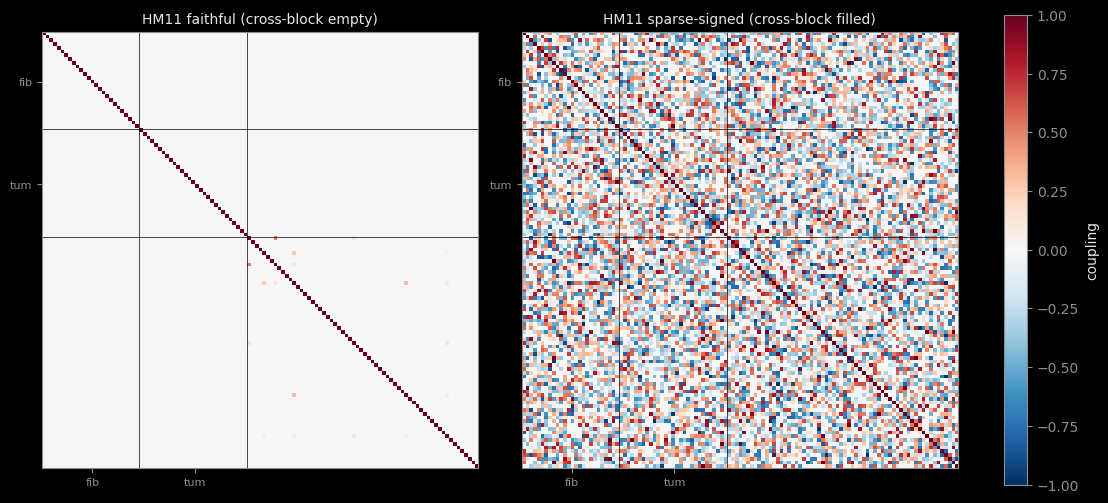

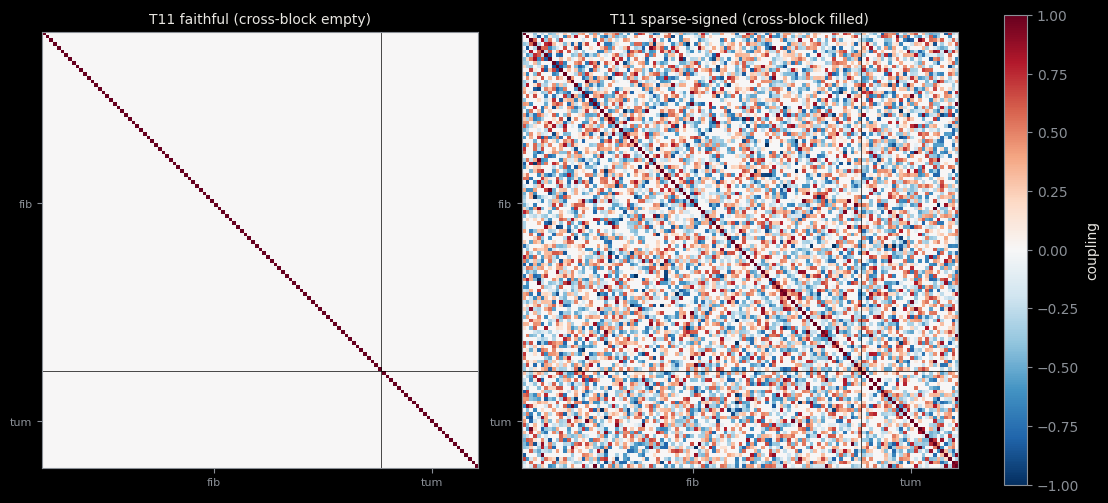

saved G2G heatmaps


In [17]:
def block_heatmap(ax, G, fib_idx, tum_idx, title):
    other=[i for i in range(len(G)) if i not in fib_idx and i not in tum_idx]
    order=fib_idx+tum_idx+other; M=G[np.ix_(order,order)]
    nz=M[np.abs(M)>1e-9]; lim=np.percentile(np.abs(nz),99) if nz.size else 1.0
    im=ax.imshow(M, cmap="RdBu_r", norm=TwoSlopeNorm(0,-lim,lim))
    nf,nt=len(fib_idx),len(tum_idx)
    for b in (nf,nf+nt): ax.axhline(b-0.5,color="k",lw=0.5); ax.axvline(b-0.5,color="k",lw=0.5)
    ax.set_title(title,fontsize=10); ax.set_xticks([nf/2,nf+nt/2]); ax.set_xticklabels(["fib","tum"],fontsize=8)
    ax.set_yticks([nf/2,nf+nt/2]); ax.set_yticklabels(["fib","tum"],fontsize=8); return im
for nm, d in data.items():
    fig,ax=plt.subplots(1,2,figsize=(11,5),constrained_layout=True)
    block_heatmap(ax[0], d["G2G_faithful"], d["fib_genes"], d["tum_genes"], f"{nm} faithful (cross-block empty)")
    im=block_heatmap(ax[1], d["G2G_sparse"], d["fib_genes"], d["tum_genes"], f"{nm} sparse-signed (cross-block filled)")
    fig.colorbar(im,ax=ax,fraction=0.04,label="coupling"); fig.savefig(f"{OUTDIR}/{nm}_G2G_heatmap.png",dpi=130,bbox_inches="tight"); plt.show()
print("saved G2G heatmaps")

### 2.2 Propagation null

If the faithful model has an empty cross block, then knocking out the fibrotic drivers should move the
tumour compartment by essentially nothing, while the signed and sparse models should move it. This is
the first sign that the cross block carries a real effect and isn't an artefact of the readout.

In [18]:
def strongest_fibrotic(d, model):
    drv,cc,g2i=d["drv"],d["cc"],d["g2i"]
    fib=[c for c in drv[drv.role=="perturb_target"].CC.unique() if str(drv[drv.CC==c].theme.iloc[0]) in FIBROTIC_THEMES]
    best,bestd,pack=None,-1e9,None; base=relax(model,d["expr"],d["edges"],d["n"])
    for c in fib:
        src=np.where(cc==c)[0]; sub=drv[(drv.CC==c)&(drv.role=="perturb_target")].head(TOP)
        gidx=[g2i[g] for g in sub.gene if g in g2i]
        if not gidx or len(src)==0: continue
        cf=relax(model,knockout(d["expr"],gidx,src),d["edges"],d["n"])
        dd=-float((cf-base)[d["tum_spots"]][:,d["tum_genes"]].mean())
        if dd>bestd: best,bestd,pack=c,dd,(src,sub,gidx)
    return best,pack,base

nm0="HM11"; d0=data[nm0]
print(f"propagation test on {nm0} (faithful vs signed vs sparse):")
faithful0=train_mode(get_loader(d0["tmp"]), d0["n"], "faithful")
signed0  =train_mode(get_loader(d0["tmp"]), d0["n"], "signed")
models3={"faithful":faithful0,"signed":signed0,"sparse":sparse_models[nm0]}
best,pack,_=strongest_fibrotic(d0, sparse_models[nm0]); src,sub,gidx=pack
rng=np.random.RandomState(SEED); null_rows=[]
for mode,mdl in models3.items():
    base=relax(mdl,d0["expr"],d0["edges"],d0["n"])
    cf=relax(mdl,knockout(d0["expr"],gidx,src),d0["edges"],d0["n"])
    drv_eff=float((cf-base)[d0["tum_spots"]][:,d0["tum_genes"]].mean())
    rnd=rng.choice(d0["n"],size=len(gidx),replace=False).tolist()
    cfr=relax(mdl,knockout(d0["expr"],rnd,src),d0["edges"],d0["n"])
    rnd_eff=float((cfr-base)[d0["tum_spots"]][:,d0["tum_genes"]].mean())
    null_rows.append({"mode":mode,"driver_tumour_delta":round(drv_eff,6),"random_tumour_delta":round(rnd_eff,6)})
    print(f"  {mode:8s} driverΔ={drv_eff:+.6f}  randomΔ={rnd_eff:+.6f}  "
          f"({'~null' if abs(drv_eff)<5e-5 else 'effect present'})")
pd.DataFrame(null_rows).to_csv(f"{OUTDIR}/propagation_null.csv", index=False)
print("saved propagation_null.csv")

propagation test on HM11 (faithful vs signed vs sparse):


100%|██████████| 200/200 [00:02<00:00, 75.69it/s]


  faithful driverΔ=+0.000007  randomΔ=+0.000015  (~null)
  signed   driverΔ=-0.000708  randomΔ=-0.000141  (effect present)
  sparse   driverΔ=-0.000878  randomΔ=-0.000479  (effect present)
saved propagation_null.csv


### 2.3 Verification battery

Three quick internal checks. The round-trip correlation confirms spherical normalization is nearly
lossless, so the coupling is learned on faithful expression. The knockout registration confirms that
setting the driver genes to their knockout state and relaxing actually lowers their expression at the
source, so the operator does what it claims. The hop decay confirms the effect is strongest near the
perturbed niche and fades with graph distance, which is what a local propagation should look like.

In [19]:
d0=data["HM11"]; mdl=sparse_models["HM11"]; expr=d0["expr"]; edges=d0["edges"]; n=d0["n"]
scm=simcomen(input_dim=n,output_dim=n,n_neighbors=K,seed=SEED); scm.to(device)
sx=torch.nan_to_num(scm.calc_sphex(torch.from_numpy(expr).to(device))); gx=scm.calc_gex(sx).detach().cpu().numpy()
rt=np.corrcoef(expr.ravel(),gx.ravel())[0,1]
print(f"[V1] round-trip corr = {rt:.4f} ({'faithful' if rt>0.99 else 'lossy'})")
best,pack,base=strongest_fibrotic(d0,mdl); src,sub,gidx=pack
cf=relax(mdl,knockout(expr,gidx,src),edges,n)
b,a_=base[np.ix_(src,gidx)].mean(),cf[np.ix_(src,gidx)].mean()
print(f"[V2] KO gene at source: {b:.4f} -> {a_:.4f} ({'registers' if a_<b*0.8 else 'did NOT take'})")
g=kneighbors_graph(d0["a"].obsm["spatial"],K,include_self=False); adj=((g+g.T)>0).astype(np.int8).tocsr()
dist=shortest_path(adj,method="D",unweighted=True,indices=src).min(0)
nonko=[i for i in range(n) if i not in gidx]; eff=np.abs(cf[:,nonko]-base[:,nonko]).mean(1)
print("[V3] effect vs hop distance:")
for hop in range(4):
    m=dist==hop
    if m.sum(): print(f"     hop {hop}: n={int(m.sum()):4d} mean_effect={eff[m].mean():.6f}")
print("     (large at source, collapses by hop 1 at the gene level)")

# ---------------------------------------------------------------------------
# [V4] SIGNED SIGN-RECOVERY (the validation the signed extension actually needs)
# Plant a SIGNED symmetric ground-truth coupling, GENERATE spatial expression with
# SCE (Simcomen), then INFER it back with the signed CCE (Celcomen) and check that
# the SIGN of the couplings round-trips. This is the signed analogue of the paper's
# Fig-1c self-consistency test and directly answers "is the signed matrix right?".
# ---------------------------------------------------------------------------
import anndata as ad
from celcomen.utils.helpers import get_pos
from scipy.stats import spearmanr

def signed_sign_recovery(n_genes=6, n_x=14, n_y=14, gen_steps=250, seed=SEED):
    try:
        rng = np.random.RandomState(seed)
        Wt = rng.uniform(-1, 1, (n_genes, n_genes)).astype("float32")
        Wt = normalize_g2g_signed((Wt + Wt.T) / 2)                 # signed symmetric ground truth
        Gi = np.eye(n_genes, dtype="float32")
        coords = get_pos(n_x, n_y); e = edges_of(coords)
        # ---- generate with SCE (Simcomen) carrying the planted signed coupling ----
        scm = simcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=K, seed=seed)
        scm.set_g2g(torch.from_numpy(Wt.copy())); scm.set_g2g_intra(torch.from_numpy(Gi.copy())); scm.to(device)
        sph0 = torch.from_numpy(rng.uniform(0, np.pi, (coords.shape[0], n_genes - 1)).astype("float32"))
        scm.set_sphex(sph0.to(device))
        opt = torch.optim.SGD(scm.parameters(), lr=1e-2, momentum=0)
        for _ in range(gen_steps):
            msg, mi, lz = scm(e.to(device), 1)
            loss = -(-lz + ZMFT*torch.trace(torch.mm(msg, scm.gex.t())) + ZMFT*torch.trace(torch.mm(mi, scm.gex.t())))
            loss.backward(); opt.step(); opt.zero_grad()
        gen = np.nan_to_num(scm.gex.detach().cpu().numpy())
        nf = np.sqrt((gen**2).sum(1, keepdims=True)); nf[nf == 0] = 1; gen = (gen/nf).astype("float32")
        # ---- infer back with signed CCE (reuse the exact working training path) ----
        A = ad.AnnData(X=csr_matrix(gen)); A.obs[SAMPLE_ID] = "0"
        A.var_names = [f"g{i}" for i in range(n_genes)]; A.obsm["spatial"] = coords
        tmp = tempfile.NamedTemporaryFile(suffix=".h5ad", delete=False).name; A.write(tmp); _TMP.append(tmp)
        mdl = train_mode(get_loader(tmp), n_genes, "signed")
        Wr = mdl.conv1.lin.weight.detach().cpu().numpy(); Wr = (Wr + Wr.T)/2
        iu = np.triu_indices(n_genes, k=1)
        wt, wr = Wt[iu], Wr[iu]
        sign_agree = float((np.sign(wt) == np.sign(wr)).mean())
        rho = float(spearmanr(wt, wr).correlation)
        neg = wt < 0
        neg_agree = float((np.sign(wt[neg]) == np.sign(wr[neg])).mean()) if neg.any() else np.nan
        return dict(sign_agreement=sign_agree, negative_sign_agreement=neg_agree, spearman=rho, n_neg=int(neg.sum()))
    except Exception as ex:
        return dict(error=str(ex))

_sr = signed_sign_recovery()
if "error" in _sr:
    print(f"[V4] signed round-trip skipped: {_sr['error']}")
else:
    print(f"[V4] signed round-trip: sign-agreement={_sr['sign_agreement']:.2f} "
          f"(negatives {_sr['negative_sign_agreement']:.2f} over {_sr['n_neg']} antagonistic pairs) "
          f"| Spearman rho={_sr['spearman']:+.2f}  "
          f"({'signs recovered' if _sr['sign_agreement']>0.7 else 'weak sign recovery'})")
    pd.DataFrame([_sr]).to_csv(f"{OUTDIR}/signed_sign_recovery.csv", index=False)


[V1] round-trip corr = 0.9985 (faithful)
[V2] KO gene at source: 0.1262 -> 0.0144 (registers)
[V3] effect vs hop distance:
     hop 0: n= 587 mean_effect=0.003925
     hop 1: n=1061 mean_effect=0.001911
     hop 2: n= 728 mean_effect=0.001948
     hop 3: n= 451 mean_effect=0.001959
     (large at source, collapses by hop 1 at the gene level)


100%|██████████| 200/200 [00:01<00:00, 196.63it/s]

[V4] signed round-trip: sign-agreement=0.93 (negatives 0.75 over 4 antagonistic pairs) | Spearman rho=+0.48  (signs recovered)


### 2.4 Niche knockout ranking

For each section, I knock out every fibrotic niche in turn and rank it by how strongly it suppresses the
tumour compartment. The winner is the niche whose removal most relieves tumour suppression, and I carry
it forward as the strongest driver niche for the dose, leave-out, and spatial experiments.

In [20]:
baseline_rows, strongest = [], {}
for nm, st in states.items():
    drv,cc,g2i=st["drv"],st["cc"],st["g2i"]
    fib=[c for c in drv[drv.role=="perturb_target"].CC.unique() if str(drv[drv.CC==c].theme.iloc[0]) in FIBROTIC_THEMES]
    print(f"\n--- {nm} niche knockout scan ---")
    rows=[]; best=None; bestd=-1e9; pack=None; cf_best=None; resp={}
    for c in fib:
        src=np.where(cc==c)[0]; sub=drv[(drv.CC==c)&(drv.role=="perturb_target")].head(TOP)
        gidx=[g2i[g] for g in sub.gene if g in g2i]
        if not gidx or len(src)==0: continue
        cf=relax(st["model"],knockout(st["expr"],gidx,src),st["edges"],st["n"])
        dvec=(cf-st["base"])[st["tum_spots"]].mean(0)
        d=float(dvec[st["tum_genes"]].mean()); down=float((dvec[st["tum_genes"]]<0).mean())
        resp[c]=pd.Series(dvec[st["tum_genes"]], index=[st["gene_names"][i] for i in st["tum_genes"]])
        rows.append({"section":nm,"niche":c,"n_spots":len(src),"drivers":",".join(sub.gene),
                     "tumour_delta":round(d,6),"tumour_down_frac":round(down,2)})
        if best is None or -d>bestd: best,bestd,pack,cf_best=c,-d,(src,sub,gidx),cf
        print(f"  {c:5s} tumourΔ={d:+.6f} down={down:.2f} drivers={','.join(sub.gene)}")
    strongest[nm]=(best,pack,cf_best,pd.DataFrame(resp).T if resp else None)
    df=pd.DataFrame(rows).sort_values("tumour_delta"); baseline_rows.append(df)
    print(f"  >> strongest fibrotic niche: {best}")
baseline_df=pd.concat(baseline_rows, ignore_index=True); baseline_df.to_csv(f"{OUTDIR}/niche_knockout.csv", index=False)
print("\nsaved niche_knockout.csv")


--- HM11 niche knockout scan ---
  CC4   tumourΔ=-0.000878 down=0.66 drivers=VIM,TIMP1,IGFBP7,CCN2,DCN
  CC6   tumourΔ=-0.000128 down=0.55 drivers=IGKC,JCHAIN,IGHA1,C7,VIM
  CC8   tumourΔ=-0.000573 down=0.59 drivers=AEBP1,IGFBP3,CCN2,IGFBP7,SPARC
  CC9   tumourΔ=-0.000107 down=0.66 drivers=C7,VIM,DCN,TIMP1,COL6A2
  CC11  tumourΔ=-0.000068 down=0.59 drivers=CCN2,AEBP1,SPARC,THBS2,COL10A1
  >> strongest fibrotic niche: CC4

--- T11 niche knockout scan ---
  CC4   tumourΔ=-0.000083 down=0.81 drivers=DES,ACTA2,FLNA,SOD3,ACTG2
  CC5   tumourΔ=-0.001675 down=0.96 drivers=COL3A1,COL1A2,DCN,COL1A1,CCN2
  CC8   tumourΔ=-0.001004 down=0.73 drivers=POSTN,IGFBP5,LCN2,PPDPF,C19orf33
  CC11  tumourΔ=-0.000579 down=0.50 drivers=TPM2,ACTA2,FBXO32,DES,FLNA
  CC14  tumourΔ=+0.000494 down=0.85 drivers=S100A6,ELF3,KRT8,MUC1,PRR15L
  >> strongest fibrotic niche: CC5

saved niche_knockout.csv


### 2.5 Control battery

A ranking only means something if it's specific. This control battery re-compares the real fibrotic
knockout against several matched controls — a random non-fibrotic niche, a random set of genes of the
same size, and shuffled versions of the graph and the labels. The real effect should stand clearly above
every control for the claim to hold.

In [21]:
def nonfibrotic_niches(st):
    drv=st["drv"]
    return [c for c in drv[drv.role=="perturb_target"].CC.unique() if str(drv[drv.CC==c].theme.iloc[0]) not in FIBROTIC_THEMES]

def control_battery(st, best, pack, n_random=N_RANDOM):
    src_rows, sub, gidx = pack
    n,expr,edges = st["n"],st["expr"],st["edges"]; tum,tum_genes,base=st["tum_spots"],st["tum_genes"],st["base"]; cc=st["cc"]
    rng=np.random.RandomState(SEED); out={}
    cf=relax(st["model"],knockout(expr,gidx,src_rows),edges,n); out["real"]=float((cf-base)[tum][:,tum_genes].mean())
    rg=[]
    for _ in range(n_random):
        rnd=rng.choice(n,size=len(gidx),replace=False).tolist()
        cf_r=relax(st["model"],knockout(expr,rnd,src_rows),edges,n); rg.append(float((cf_r-base)[tum][:,tum_genes].mean()))
    out["random_gene_mean"]=float(np.mean(rg)); out["random_gene_sd"]=float(np.std(rg))
    # random non-fibrotic niche, averaged over up to 3 draws (robust, not a single draw)
    nf=nonfibrotic_niches(st); rn=[]
    if nf:
        for rc in rng.choice(nf, size=min(3,len(nf)), replace=False):
            rsrc=np.where(cc==rc)[0]; rsub=st["drv"][(st["drv"].CC==rc)&(st["drv"].role=="perturb_target")].head(TOP)
            rgidx=[st["g2i"][g] for g in rsub.gene if g in st["g2i"]]
            if rgidx and len(rsrc):
                cf_n=relax(st["model"],knockout(expr,rgidx,rsrc),edges,n); rn.append(float((cf_n-base)[tum][:,tum_genes].mean()))
    out["random_niche_mean"]=float(np.mean(rn)) if rn else np.nan
    # shuffled spatial graph (retrain on shuffled coords)
    rsh=np.random.RandomState(1000+SEED); coords=st["a"].obsm["spatial"].copy(); rsh.shuffle(coords)
    edges_sh=edges_of(coords); a_sh=st["a"].copy(); a_sh.obsm["spatial"]=coords
    tmp_sh=tempfile.NamedTemporaryFile(suffix=".h5ad",delete=False).name; a_sh.write(tmp_sh)
    model_sh=train_sparse(get_loader(tmp_sh), n); os.unlink(tmp_sh)
    base_sh=relax(model_sh,expr,edges_sh,n); cf_sh=relax(model_sh,knockout(expr,gidx,src_rows),edges_sh,n)
    out["shuffled_graph"]=float((cf_sh-base_sh)[tum][:,tum_genes].mean())
    # shuffled labels (random source spots, same count)
    rr=np.random.RandomState(2000+SEED).choice(st["a"].n_obs,size=max(1,len(src_rows)),replace=False)
    cf_sl=relax(st["model"],knockout(expr,gidx,rr),edges,n); out["shuffled_labels"]=float((cf_sl-base)[tum][:,tum_genes].mean())
    out["specificity"]=abs(out["real"])/(abs(out["random_gene_mean"])+1e-12)
    return out

ctrl_rows=[]
for nm, st in states.items():
    best,pack,_,_=strongest[nm]
    if pack is None: continue
    print(f"\n--- {nm} control battery (niche {best}) ---")
    cb=control_battery(st,best,pack)
    for k in ["real","random_gene_mean","random_niche_mean","shuffled_graph","shuffled_labels"]:
        print(f"  {k:18s} = {cb[k]:+.6f}" if np.isfinite(cb[k]) else f"  {k:18s} = NA")
    print(f"  specificity (real/random) = {cb['specificity']:.2f} ({'passes (>1.5)' if cb['specificity']>1.5 else 'weak'})")
    cb["section"]=nm; cb["niche"]=best; ctrl_rows.append(cb)
pd.DataFrame(ctrl_rows).to_csv(f"{OUTDIR}/controls.csv", index=False); print("\nsaved controls.csv")


--- HM11 control battery (niche CC4) ---


100%|██████████| 200/200 [00:01<00:00, 134.20it/s]


  real               = -0.000878
  random_gene_mean   = -0.000050
  random_niche_mean  = -0.007665
  shuffled_graph     = -0.000865
  shuffled_labels    = -0.000104
  specificity (real/random) = 17.43 (passes (>1.5))

--- T11 control battery (niche CC5) ---


100%|██████████| 200/200 [00:01<00:00, 138.27it/s]


  real               = -0.001675
  random_gene_mean   = -0.000191
  random_niche_mean  = -0.006009
  shuffled_graph     = -0.001670
  shuffled_labels    = -0.000406
  specificity (real/random) = 8.78 (passes (>1.5))

saved controls.csv


### 2.6 Dose response

Instead of a full knockout, I scale the strongest niche across a range of doses from full removal to
overexpression. If the stroma-to-tumour link is real and roughly monotone, the tumour response should
track the dose in a smooth, interpretable way.

In [22]:
dose_rows=[]
for nm, st in states.items():
    best,pack,_,_=strongest[nm]
    if pack is None: continue
    src,sub,gidx=pack
    for f in DOSES:
        cf=relax(st["model"],dose_perturb(st["expr"],gidx,src,f),st["edges"],st["n"])
        d=float((cf-st["base"])[st["tum_spots"]][:,st["tum_genes"]].mean())
        tag="KO" if f==0 else ("baseline" if f==1 else ("overexpr" if f>1 else "knockdown"))
        dose_rows.append({"section":nm,"niche":best,"dose":f,"tumour_delta":round(d,6),"kind":tag})
        print(f"  {nm} dose={f:.2f} ({tag:9s}) tumourΔ={d:+.6f}")
dose_df=pd.DataFrame(dose_rows); dose_df.to_csv(f"{OUTDIR}/dose_response.csv", index=False); print("saved dose_response.csv")

  HM11 dose=0.00 (KO       ) tumourΔ=-0.000878
  HM11 dose=0.25 (knockdown) tumourΔ=-0.000638
  HM11 dose=0.50 (knockdown) tumourΔ=-0.000410
  HM11 dose=0.75 (knockdown) tumourΔ=-0.000197
  HM11 dose=1.00 (baseline ) tumourΔ=-0.000001
  HM11 dose=1.50 (overexpr ) tumourΔ=+0.000336
  HM11 dose=2.00 (overexpr ) tumourΔ=+0.000604
  T11 dose=0.00 (KO       ) tumourΔ=-0.001675
  T11 dose=0.25 (knockdown) tumourΔ=-0.001156
  T11 dose=0.50 (knockdown) tumourΔ=-0.000703
  T11 dose=0.75 (knockdown) tumourΔ=-0.000319
  T11 dose=1.00 (baseline ) tumourΔ=+0.000001
  T11 dose=1.50 (overexpr ) tumourΔ=+0.000466
  T11 dose=2.00 (overexpr ) tumourΔ=+0.000747
saved dose_response.csv


### 2.7 Leaving out one driver at a time

Is the effect carried by a single driver gene or shared across the program? I remove each driver from
the knockout set in turn and measure the loss of effect. A distributed program shows a gentle drop
whichever gene is left out, whereas a single carrier shows one large drop.

In [23]:
loo_rows=[]
for nm, st in states.items():
    best,pack,_,_=strongest[nm]
    if pack is None: continue
    src,sub,gidx=pack
    cf_full=relax(st["model"],knockout(st["expr"],gidx,src),st["edges"],st["n"])
    full=-float((cf_full-st["base"])[st["tum_spots"]][:,st["tum_genes"]].mean())
    print(f"\n--- {nm} {best}: full suppression={full:+.6f} ---")
    for j,gname in enumerate(sub.gene):
        keep=[g for i,g in enumerate(gidx) if i!=j]
        cf=relax(st["model"],knockout(st["expr"],keep,src),st["edges"],st["n"])
        supp=-float((cf-st["base"])[st["tum_spots"]][:,st["tum_genes"]].mean())
        loo_rows.append({"section":nm,"niche":best,"gene":gname,"suppression_without_gene":round(supp,6),"contribution":round(full-supp,6)})
        print(f"  leave out {gname:8s} -> contribution={full-supp:+.6f}")
loo_df=pd.DataFrame(loo_rows).sort_values(["section","contribution"],ascending=[True,False]); loo_df.to_csv(f"{OUTDIR}/leave_one_out.csv", index=False)
print("\nsaved leave_one_out.csv")


--- HM11 CC4: full suppression=+0.000878 ---
  leave out VIM      -> contribution=+0.000023
  leave out TIMP1    -> contribution=+0.000313
  leave out IGFBP7   -> contribution=+0.000197
  leave out CCN2     -> contribution=+0.000206
  leave out DCN      -> contribution=+0.000178

--- T11 CC5: full suppression=+0.001675 ---
  leave out COL3A1   -> contribution=+0.000393
  leave out COL1A2   -> contribution=+0.000415
  leave out DCN      -> contribution=+0.000345
  leave out COL1A1   -> contribution=+0.000385
  leave out CCN2     -> contribution=+0.000243

saved leave_one_out.csv


### 2.8 Differential control between primary and metastasis

I perturb the same core fibrotic program in both sections and compare the per-tumour-gene response. This
asks which tumour genes the stroma controls differently in the primary versus the metastasis, which is
where the matched design earns its value.

In [24]:
def fib_rows(st):
    drv,cc=st["drv"],st["cc"]
    fib=[c for c in drv[drv.role=="perturb_target"].CC.unique() if str(drv[drv.CC==c].theme.iloc[0]) in FIBROTIC_THEMES]
    return np.where(np.isin(cc,fib))[0]
per_gene={}
for nm, st in states.items():
    gidx=[st["g2i"][g] for g in SHARED_DRIVERS if g in st["g2i"]]; rows=fib_rows(st)
    cf=relax(st["model"],knockout(st["expr"],gidx,rows),st["edges"],st["n"])
    per_gene[nm]=pd.Series((cf-st["base"])[st["tum_spots"]].mean(0), index=st["gene_names"])
    print(f"  {nm}: KO {[g for g in SHARED_DRIVERS if g in st['g2i']]} in {len(rows)} fibrotic spots")
tg=sorted(set(st["gene_names"][i] for st in states.values() for i in st["tum_genes"]))
diff_df=pd.DataFrame([{"gene":g,"T11_primary_delta":round(float(per_gene["T11"].get(g,np.nan)),6),
                       "HM11_met_delta":round(float(per_gene["HM11"].get(g,np.nan)),6),
                       "difference_met_minus_primary":round(float(per_gene["HM11"].get(g,np.nan)-per_gene["T11"].get(g,np.nan)),6)} for g in tg]
                     ).sort_values("difference_met_minus_primary")
diff_df.to_csv(f"{OUTDIR}/differential_response.csv", index=False)
print("\n(pooled-stroma KO; coarser than per-niche) top differential genes:")
print(diff_df.head(3).to_string(index=False)); print(diff_df.tail(3).to_string(index=False))

  HM11: KO ['CCN2', 'SPARC', 'DCN', 'TIMP1', 'IGFBP7'] in 1751 fibrotic spots
  T11: KO ['CCN2', 'SPARC', 'DCN', 'TIMP1', 'IGFBP7'] in 2583 fibrotic spots

(pooled-stroma KO; coarser than per-niche) top differential genes:
  gene  T11_primary_delta  HM11_met_delta  difference_met_minus_primary
  SLPI           0.012231        0.004401                     -0.007829
  PLS1           0.012066        0.004424                     -0.007641
SPINT2           0.010447        0.004139                     -0.006308
    gene  T11_primary_delta  HM11_met_delta  difference_met_minus_primary
LGALS3BP          -0.018148       -0.009153                      0.008994
    ELF3          -0.018653       -0.008309                      0.010344
   ABCC3          -0.037016       -0.016778                      0.020238


### 2.9 Bidirectional crosstalk

Direction matters. This measures whether perturbing the fibrotic drivers moves the tumour more than
perturbing the tumour drivers moves the stroma, using size-matched driver sets so the comparison is
fair. A clear asymmetry is the observational hint that the stroma sits upstream.

In [25]:
def drivers_of(st, themes):
    drv,g2i=st["drv"],st["g2i"]; sel=drv[(drv.role=="perturb_target")&(drv.theme.isin(themes))]; genes=[]
    for c in sel.CC.unique(): genes+=list(drv[(drv.CC==c)&(drv.role=="perturb_target")].head(TOP).gene)
    return [g2i[g] for g in dict.fromkeys(genes) if g in g2i]
bidir_rows=[]
for nm, st in states.items():
    fd=drivers_of(st,list(FIBROTIC_THEMES)); td=drivers_of(st,list(TUMOUR_THEMES))
    nf=int(st["fib_spots"].sum()); nt=int(st["tum_spots"].sum())
    cf_f=relax(st["model"],knockout(st["expr"],fd,np.where(st["fib_spots"])[0]),st["edges"],st["n"])
    fwd=float((cf_f-st["base"])[st["tum_spots"]][:,st["tum_genes"]].mean())
    cf_r=relax(st["model"],knockout(st["expr"],td,np.where(st["tum_spots"])[0]),st["edges"],st["n"])
    rev=float((cf_r-st["base"])[st["fib_spots"]][:,st["fib_genes"]].mean())
    raw=abs(fwd)/(abs(rev)+1e-12); norm=(abs(fwd)/max(len(fd),1))/((abs(rev)/max(len(td),1))+1e-12)
    who="stroma drives" if raw>1.3 else ("tumour drives" if raw<0.77 else "symmetric")
    bidir_rows.append({"section":nm,"stroma_to_tumour":round(fwd,6),"tumour_to_stroma":round(rev,6),
                       "raw_asymmetry":round(raw,2),"norm_per_driver":round(norm,2),"n_fib_spots":nf,"n_tum_spots":nt,"direction":who})
    print(f"  {nm}: stroma→tumour={fwd:+.6f} tumour→stroma={rev:+.6f} | raw={raw:.1f} per-driver={norm:.1f} (sizes fib={nf} tum={nt}) -> {who}")
pd.DataFrame(bidir_rows).to_csv(f"{OUTDIR}/bidirectional.csv", index=False)
print("saved bidirectional.csv  (interpret direction + gradient, not absolute magnitude)")

  HM11: stroma→tumour=-0.004536 tumour→stroma=-0.001644 | raw=2.8 per-driver=2.8 (sizes fib=1751 tum=714) -> stroma drives
  T11: stroma→tumour=-0.013523 tumour→stroma=-0.000129 | raw=104.9 per-driver=33.4 (sizes fib=2583 tum=185) -> stroma drives
saved bidirectional.csv  (interpret direction + gradient, not absolute magnitude)


### 2.10 Spatial dose response

I repeat the dose response as a function of graph distance from the perturbed niche. If dose sensitivity
is stronger near the interface and weaker far away, the effect is spatially organized rather than
uniform, which fits with local crosstalk at the tumour margin.

In [26]:
sp_rows=[]
for nm, st in states.items():
    best,pack,_,_=strongest[nm]
    if pack is None: continue
    src,sub,gidx=pack
    g=kneighbors_graph(st["a"].obsm["spatial"],K,include_self=False); adj=((g+g.T)>0).astype(np.int8).tocsr()
    dist=shortest_path(adj,method="D",unweighted=True,indices=src).min(0)
    near=st["tum_spots"]&(dist<=2); deep=st["tum_spots"]&(dist>=4)
    for f in DOSES:
        cf=relax(st["model"],dose_perturb(st["expr"],gidx,src,f),st["edges"],st["n"]); dd=cf-st["base"]
        dn=float(dd[near][:,st["tum_genes"]].mean()) if near.sum() else np.nan
        dp=float(dd[deep][:,st["tum_genes"]].mean()) if deep.sum() else np.nan
        sp_rows.append({"section":nm,"niche":best,"dose":f,"interface_delta":round(dn,6),"deep_delta":round(dp,6)})
    sdf=pd.DataFrame([r for r in sp_rows if r["section"]==nm and r["dose"]<=1.0])
    sn=np.polyfit(sdf.dose,sdf.interface_delta,1)[0]; sd=np.polyfit(sdf.dose,sdf.deep_delta,1)[0]
    print(f"  {nm} ({best}): interface n={int(near.sum())} deep n={int(deep.sum())} | slope interface={sn:+.5f} deep={sd:+.5f} "
          f"({'interface more sensitive' if abs(sn)>abs(sd)*1.2 else 'similar'})")
pd.DataFrame(sp_rows).to_csv(f"{OUTDIR}/spatial_dose.csv", index=False); print("saved spatial_dose.csv")

  HM11 (CC4): interface n=316 deep n=268 | slope interface=+0.00085 deep=+0.00090 (similar)
  T11 (CC5): interface n=43 deep n=127 | slope interface=+0.00169 deep=+0.00167 (similar)
saved spatial_dose.csv


### 2.11 Robustness across seeds

I retrain the couplings under several random seeds and recompute the key findings each time. The point
is to show the ranking and the dose direction don't depend on one lucky initialization.

100%|██████████| 200/200 [00:01<00:00, 136.13it/s]


  seed 0 HM11: top=CC4 suppression=+0.000878 spec=2.91 signflip=True


100%|██████████| 200/200 [00:01<00:00, 145.58it/s]


  seed 0 T11: top=CC5 suppression=+0.001675 spec=6.26 signflip=True


100%|██████████| 200/200 [00:01<00:00, 132.94it/s]


...

  seed 1 T11: top=CC8 suppression=+0.001549 spec=3.28 signflip=True


100%|██████████| 200/200 [00:01<00:00, 134.06it/s]


  seed 2 HM11: top=CC4 suppression=+0.001053 spec=17.86 signflip=True


100%|██████████| 200/200 [00:01<00:00, 146.68it/s]


  seed 2 T11: top=CC5 suppression=+0.001519 spec=7.52 signflip=True

HM11: top niche VARIES (CC4); suppression=+0.001020±0.000129; spec=8.04; dose sign-flip all seeds=True

T11: top niche VARIES (CC5); suppression=+0.001581±0.000083; spec=5.69; dose sign-flip all seeds=True


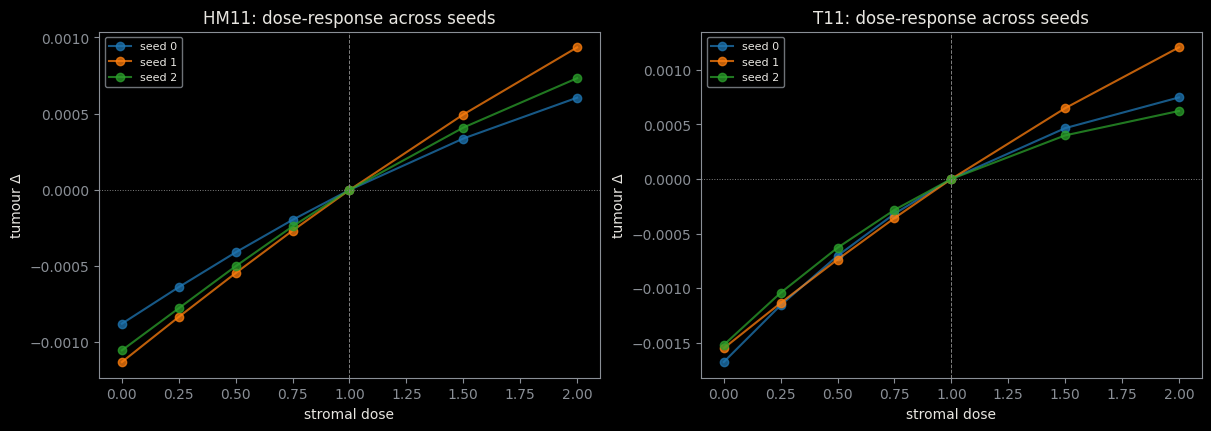


saved robustness_per_seed.csv, robustness_summary.csv, robustness_dose_curves.png


In [27]:
rob_per_seed=[]; rob_dose={}
for seed in SEEDS:
    for nm, d in data.items():
        model = train_for_seed(get_loader(d["tmp"]), d["n"], seed)
        base = relax(model, d["expr"], d["edges"], d["n"])
        drv,cc,g2i=d["drv"],d["cc"],d["g2i"]
        fib=[c for c in drv[drv.role=="perturb_target"].CC.unique() if str(drv[drv.CC==c].theme.iloc[0]) in FIBROTIC_THEMES]
        best=None; bestd=-1e9; bestpack=None
        for c in fib:
            src=np.where(cc==c)[0]; sub=drv[(drv.CC==c)&(drv.role=="perturb_target")].head(TOP)
            gidx=[g2i[g] for g in sub.gene if g in g2i]
            if not gidx or len(src)==0: continue
            cf=relax(model,knockout(d["expr"],gidx,src),d["edges"],d["n"])
            dd=-float((cf-base)[d["tum_spots"]][:,d["tum_genes"]].mean())
            if dd>bestd: best,bestd,bestpack=c,dd,(src,gidx)
        src,gidx=bestpack
        rng=np.random.RandomState(seed); rg=[]
        for _ in range(3):
            rnd=rng.choice(d["n"],size=len(gidx),replace=False).tolist()
            cfr=relax(model,knockout(d["expr"],rnd,src),d["edges"],d["n"]); rg.append(-float((cfr-base)[d["tum_spots"]][:,d["tum_genes"]].mean()))
        spec=abs(bestd)/(abs(np.mean(rg))+1e-12)
        dvals=[]
        for f in DOSES:
            cf=relax(model,dose_perturb(d["expr"],gidx,src,f),d["edges"],d["n"])
            dvals.append(float((cf-base)[d["tum_spots"]][:,d["tum_genes"]].mean()))
        rob_dose[(seed,nm)]=dvals; signflip=bool(np.sign(dvals[0])*np.sign(dvals[-1])<0)
        rob_per_seed.append({"seed":seed,"section":nm,"top_niche":best,"suppression":round(bestd,6),
                             "specificity":round(spec,2),"dose_sign_flip":signflip})
        print(f"  seed {seed} {nm}: top={best} suppression={bestd:+.6f} spec={spec:.2f} signflip={signflip}")
rob_df=pd.DataFrame(rob_per_seed); rob_df.to_csv(f"{OUTDIR}/robustness_per_seed.csv", index=False)
rob_summary={}
for nm in data:
    sub=rob_df[rob_df.section==nm]; tc=sub.top_niche.value_counts()
    rob_summary[nm]=dict(top_niche_mode=tc.index[0], top_niche_consistent=bool(tc.iloc[0]==len(sub)),
                         suppression_mean=float(sub.suppression.mean()), suppression_sd=float(sub.suppression.std()),
                         specificity_mean=float(sub.specificity.mean()), signflip_all=bool(sub.dose_sign_flip.all()))
    s=rob_summary[nm]
    print(f"\n{nm}: top niche {'CONSISTENT' if s['top_niche_consistent'] else 'VARIES'} ({s['top_niche_mode']}); "
          f"suppression={s['suppression_mean']:+.6f}±{s['suppression_sd']:.6f}; spec={s['specificity_mean']:.2f}; "
          f"dose sign-flip all seeds={s['signflip_all']}")
pd.DataFrame(rob_summary).T.to_csv(f"{OUTDIR}/robustness_summary.csv")
fig,ax=plt.subplots(1,len(data),figsize=(6*len(data),4.2),squeeze=False,constrained_layout=True)
for j,nm in enumerate(data):
    for seed in SEEDS: ax[0][j].plot(DOSES, rob_dose[(seed,nm)], "o-", alpha=0.75, label=f"seed {seed}")
    ax[0][j].axhline(0,color="grey",lw=0.7,ls=":"); ax[0][j].axvline(1,color="grey",lw=0.7,ls="--")
    ax[0][j].set_title(f"{nm}: dose-response across seeds"); ax[0][j].set_xlabel("stromal dose"); ax[0][j].set_ylabel("tumour Δ"); ax[0][j].legend(fontsize=8)
fig.savefig(f"{OUTDIR}/robustness_dose_curves.png",dpi=130,bbox_inches="tight"); plt.show()
print("\nsaved robustness_per_seed.csv, robustness_summary.csv, robustness_dose_curves.png")

### 2.12 Synergy between niches

Finally, I knock out pairs of the top fibrotic niches together and compare that to the sum of their
single effects. If the joint effect exceeds the sum, the niches cooperate rather than acting
independently, which is a stronger statement about the tissue than any single niche result.

100%|██████████| 200/200 [00:01<00:00, 132.93it/s]


  seed0 HM11 CC4+CC8: obs=+0.00235 exp=+0.00145 syn=+0.00090 -> synergistic
  seed0 HM11 CC4+CC6: obs=+0.00174 exp=+0.00101 syn=+0.00073 -> synergistic
  seed0 HM11 CC8+CC6: obs=+0.00132 exp=+0.00070 syn=+0.00062 -> synergistic


100%|██████████| 200/200 [00:01<00:00, 144.50it/s]


  seed0 T11 CC5+CC8: obs=+0.00596 exp=+0.00268 syn=+0.00328 -> synergistic
  seed0 T11 CC5+CC11: obs=+0.00536 exp=+0.00225 syn=+0.00311 -> synergistic
  seed0 T11 CC8+CC11: obs=+0.00361 exp=+0.00158 syn=+0.00203 -> synergistic


100%|██████████| 200/200 [00:01<00:00, 132.55it/s]


...

  seed1 T11 CC8+CC5: obs=+0.00549 exp=+0.00266 syn=+0.00283 -> synergistic
  seed1 T11 CC8+CC11: obs=+0.00487 exp=+0.00229 syn=+0.00258 -> synergistic
  seed1 T11 CC5+CC11: obs=+0.00429 exp=+0.00185 syn=+0.00244 -> synergistic


100%|██████████| 200/200 [00:01<00:00, 119.73it/s]


  seed2 HM11 CC4+CC8: obs=+0.00328 exp=+0.00189 syn=+0.00139 -> synergistic
  seed2 HM11 CC4+CC6: obs=+0.00172 exp=+0.00124 syn=+0.00048 -> synergistic
  seed2 HM11 CC8+CC6: obs=+0.00190 exp=+0.00102 syn=+0.00088 -> synergistic


100%|██████████| 200/200 [00:01<00:00, 143.00it/s]


  seed2 T11 CC5+CC8: obs=+0.00605 exp=+0.00275 syn=+0.00330 -> synergistic
  seed2 T11 CC5+CC4: obs=+0.00236 exp=+0.00162 syn=+0.00074 -> synergistic
  seed2 T11 CC8+CC4: obs=+0.00268 exp=+0.00134 syn=+0.00134 -> synergistic

synergy summary across seeds:
section niche_A niche_B  mean_synergy  sd_synergy  mean_observed  mean_expected  label_mode
   HM11     CC4    CC11      0.000814         NaN       0.001948       0.001134 synergistic
   HM11     CC4     CC6      0.000605    0.000176       0.001730       0.001124 synergistic
   HM11     CC4     CC8      0.001146    0.000350       0.002816       0.001670 synergistic
   HM11     CC8    CC11      0.000078         NaN       0.001372       0.001294    additive
   HM11     CC8     CC4      0.001508         NaN       0.003607       0.002100 synergistic
   HM11     CC8     CC6      0.000750    0.000185       0.001612       0.000863 synergistic
    T11     CC5    CC11      0.002774    0.000470       0.004826       0.002052 synergistic
    T11 

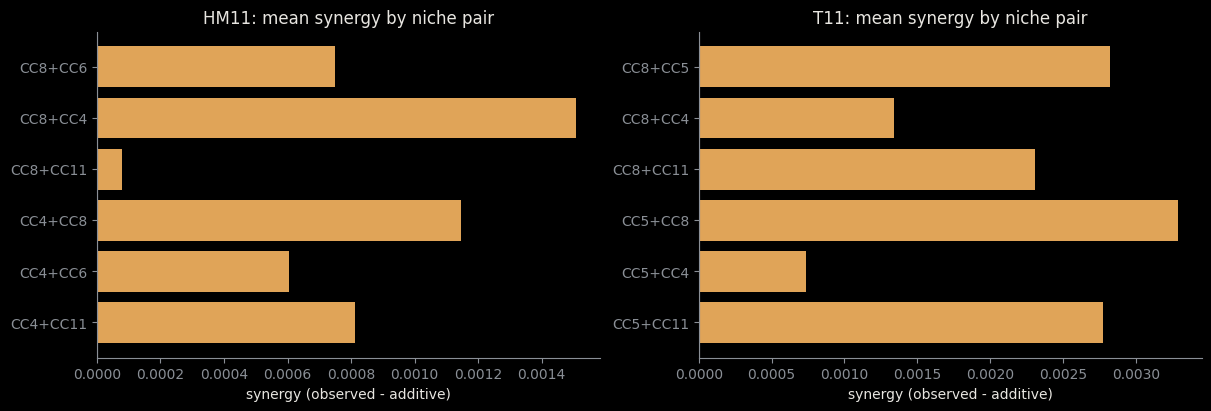

saved synergy_results.csv, synergy_summary.csv, synergy.png


In [28]:
def _supp(model, expr, edges, n, base, tum_mask, tum_idx, gidx, rows):
    cf = relax(model, knockout(expr, gidx, rows), edges, n)
    return -float((cf - base)[tum_mask][:, tum_idx].mean())   # positive = tumour suppressed

syn_rows=[]
for seed in SEEDS:
    for nm, d in data.items():
        model = train_for_seed(get_loader(d["tmp"]), d["n"], seed)
        base = relax(model, d["expr"], d["edges"], d["n"])
        drv,cc,g2i = d["drv"], d["cc"], d["g2i"]
        tum_mask, tum_idx = d["tum_spots"], d["tum_genes"]
        fib=[c for c in drv[drv.role=="perturb_target"].CC.unique()
             if str(drv[drv.CC==c].theme.iloc[0]) in FIBROTIC_THEMES]
        single={}
        for c in fib:
            rows=np.where(cc==c)[0]; sub=drv[(drv.CC==c)&(drv.role=="perturb_target")].head(TOP)
            gidx=[g2i[g] for g in sub.gene if g in g2i]
            if not gidx or len(rows)==0: continue
            single[c]=dict(supp=_supp(model,d["expr"],d["edges"],d["n"],base,tum_mask,tum_idx,gidx,rows),
                           rows=rows, gidx=gidx)
        top=sorted(single, key=lambda c: single[c]["supp"], reverse=True)[:N_TOP_NICHES]
        for A,B in combinations(top,2):
            sA,sB=single[A]["supp"],single[B]["supp"]
            gidx_AB=list(dict.fromkeys(single[A]["gidx"]+single[B]["gidx"]))
            rows_AB=np.union1d(single[A]["rows"],single[B]["rows"])
            sAB=_supp(model,d["expr"],d["edges"],d["n"],base,tum_mask,tum_idx,gidx_AB,rows_AB)
            synergy=sAB-(sA+sB); tol=0.10*(abs(sA)+abs(sB)+1e-12)
            lab=("synergistic" if synergy>tol else "redundant/antagonistic" if synergy<-tol else "additive")
            syn_rows.append({"section":nm,"seed":seed,"niche_A":A,"niche_B":B,
                             "supp_A":round(sA,6),"supp_B":round(sB,6),
                             "expected_additive":round(sA+sB,6),"observed_combined":round(sAB,6),
                             "synergy":round(synergy,6),"type":lab})
            print(f"  seed{seed} {nm} {A}+{B}: obs={sAB:+.5f} exp={sA+sB:+.5f} syn={synergy:+.5f} -> {lab}")
syn_df=pd.DataFrame(syn_rows); syn_df.to_csv(f"{OUTDIR}/synergy_results.csv", index=False)
if len(syn_df):
    syn_summary=(syn_df.groupby(["section","niche_A","niche_B"])
        .agg(mean_synergy=("synergy","mean"), sd_synergy=("synergy","std"),
             mean_observed=("observed_combined","mean"), mean_expected=("expected_additive","mean"),
             label_mode=("type", lambda s: s.value_counts().idxmax())).reset_index().round(6))
    syn_summary.to_csv(f"{OUTDIR}/synergy_summary.csv", index=False)
    print("\nsynergy summary across seeds:"); print(syn_summary.to_string(index=False))
    # black-background plot
    fig,axes=plt.subplots(1,len(data),figsize=(6*len(data),4),squeeze=False,constrained_layout=True)
    for ax,nm in zip(axes[0],data):
        sub=syn_summary[syn_summary.section==nm]
        if not len(sub): ax.axis("off"); ax.set_title(f"{nm}: no pairs"); continue
        pairs=[f"{r.niche_A}+{r.niche_B}" for _,r in sub.iterrows()]
        ax.barh(pairs, sub.mean_synergy.values, color=_ACCENT)
        ax.axvline(0,color=_MUTE,lw=0.8)
        ax.set_title(f"{nm}: mean synergy by niche pair"); ax.set_xlabel("synergy (observed - additive)")
        ax.spines[["top","right"]].set_visible(False)
    fig.savefig(f"{OUTDIR}/synergy.png",dpi=140,facecolor=_BLACK); plt.show()
    print("saved synergy_results.csv, synergy_summary.csv, synergy.png")
else:
    syn_summary=pd.DataFrame(); print("no niche pairs (need >=2 fibrotic niches per section)")

### 2.13 Summary figures

The niche response heatmaps, the spatial maps, the dose curves, and the leave-out and bidirectional bars
all get drawn together so the experiments can be read at a glance.

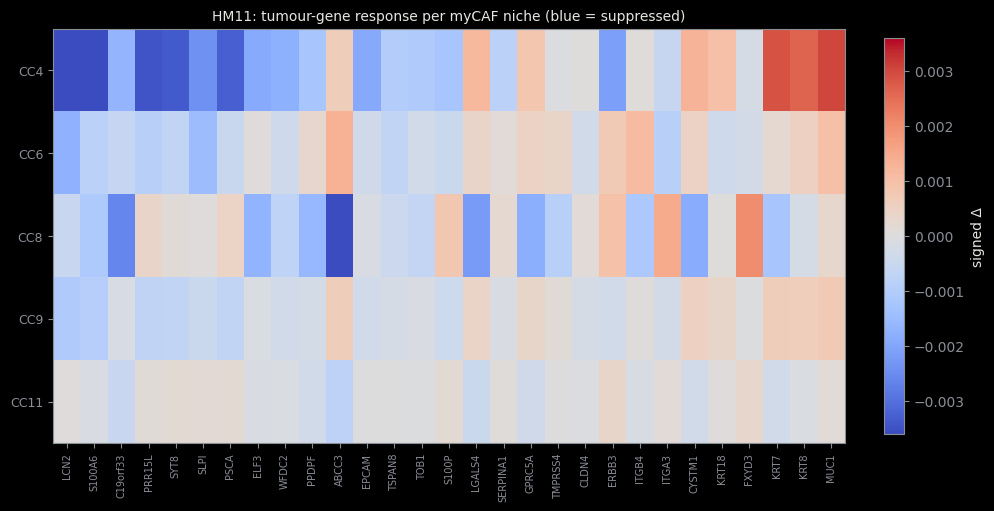

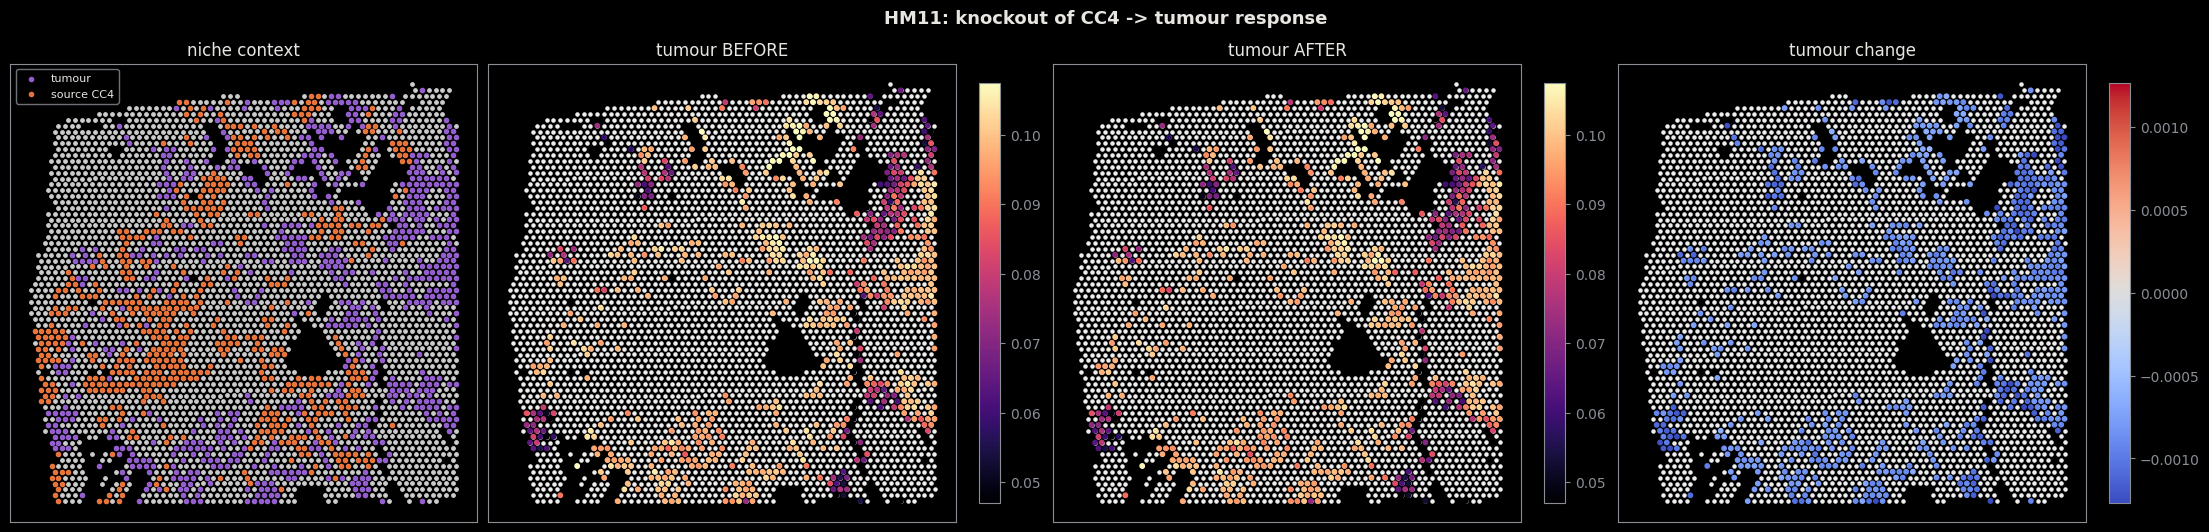

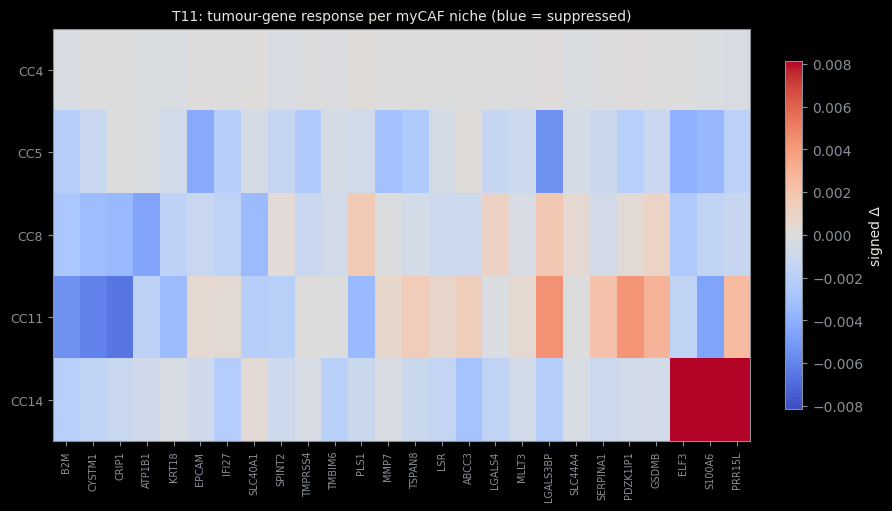

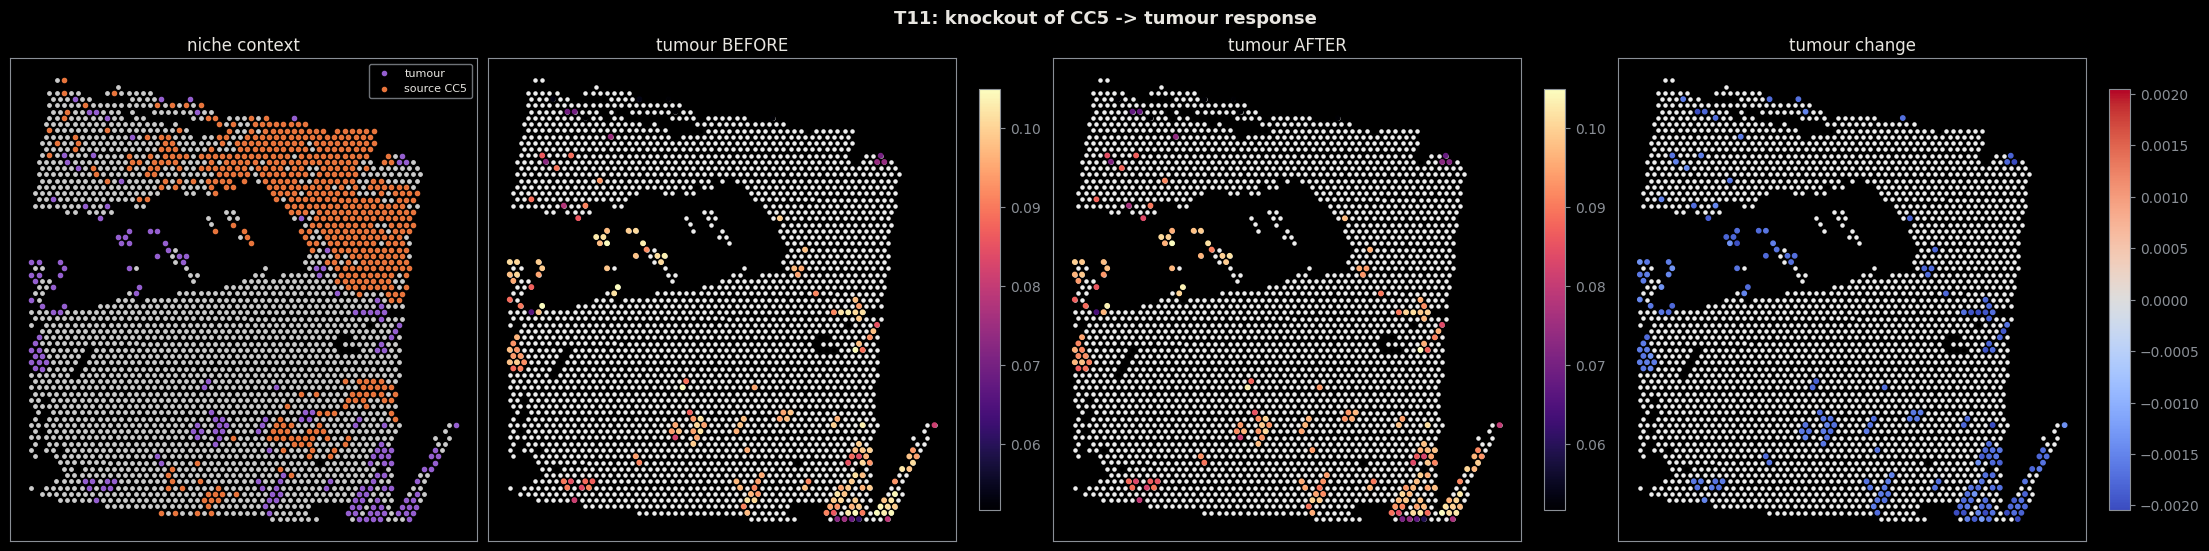

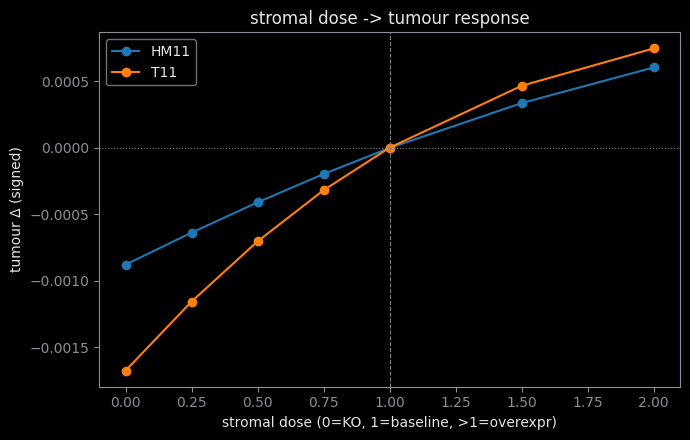

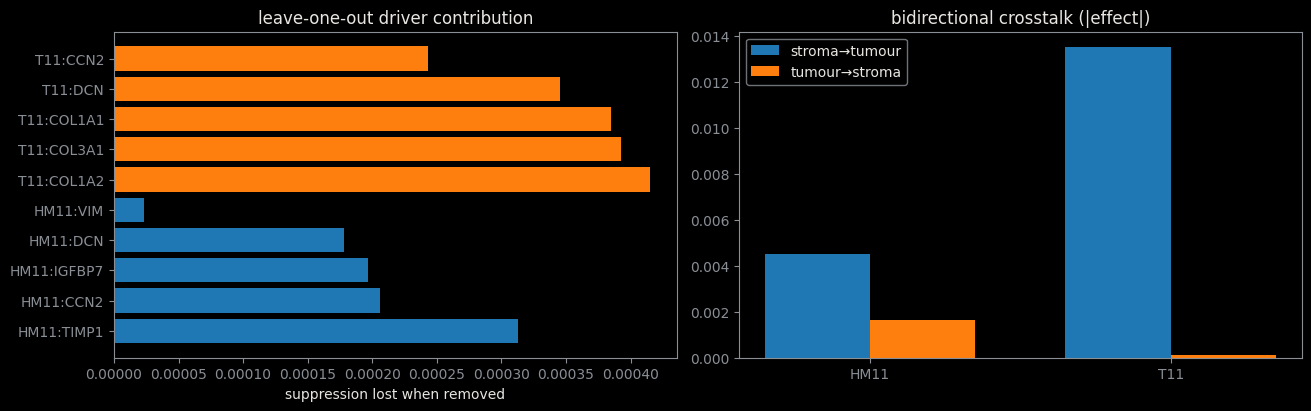

saved all figures


In [29]:
for nm, st in states.items():
    best,pack,cf_best,resp_df=strongest[nm]
    if resp_df is not None and len(resp_df):
        rd=resp_df[resp_df.mean(0).sort_values().index]
        fig,ax=plt.subplots(figsize=(max(8,rd.shape[1]*0.34),0.6*len(rd)+2),constrained_layout=True)
        lim=np.percentile(np.abs(rd.values),98)+1e-12
        im=ax.imshow(rd.values,cmap="coolwarm",norm=TwoSlopeNorm(0,-lim,lim),aspect="auto")
        ax.set_xticks(range(rd.shape[1])); ax.set_xticklabels(rd.columns,rotation=90,fontsize=7)
        ax.set_yticks(range(len(rd))); ax.set_yticklabels(rd.index,fontsize=9)
        ax.set_title(f"{nm}: tumour-gene response per myCAF niche (blue = suppressed)",fontsize=10)
        fig.colorbar(im,ax=ax,fraction=0.025,label="signed Δ"); fig.savefig(f"{OUTDIR}/{nm}_niche_response_heatmap.png",dpi=130,bbox_inches="tight"); plt.show()
    if cf_best is not None:
        coords=st["a"].obsm["spatial"]; cc=st["cc"]; tum=st["tum_spots"]; tg=st["tum_genes"]
        before=st["base"][:,tg].mean(1); after=cf_best[:,tg].mean(1); diff=after-before; src_mask=(cc==best); x,y=coords[:,0],coords[:,1]
        fig,ax=plt.subplots(1,4,figsize=(22,5.4),constrained_layout=True)
        ax[0].scatter(x,y,s=6,c="#cccccc"); ax[0].scatter(x[tum],y[tum],s=9,c="#945ecf",label="tumour")
        ax[0].scatter(x[src_mask],y[src_mask],s=9,c="#e8743b",label=f"source {best}"); ax[0].legend(fontsize=8); ax[0].set_title("niche context")
        vlo,vhi=np.percentile(np.r_[before[tum],after[tum]],[2,98])
        for axi,val,t in [(ax[1],before,"tumour BEFORE"),(ax[2],after,"tumour AFTER")]:
            axi.scatter(x,y,s=5,c="#eee"); s2=axi.scatter(x[tum],y[tum],s=10,c=val[tum],cmap="magma",vmin=vlo,vmax=vhi); axi.set_title(t); fig.colorbar(s2,ax=axi,fraction=0.045)
        lim=np.percentile(np.abs(diff[tum]),98)+1e-12
        s3=ax[3].scatter(x[tum],y[tum],s=10,c=diff[tum],cmap="coolwarm",norm=TwoSlopeNorm(0,-lim,lim)); ax[3].scatter(x[~tum],y[~tum],s=5,c="#eee"); ax[3].set_title("tumour change"); fig.colorbar(s3,ax=ax[3],fraction=0.045)
        for a_ in ax: a_.set_xticks([]); a_.set_yticks([]); a_.set_aspect("equal")
        fig.suptitle(f"{nm}: knockout of {best} -> tumour response",fontsize=13,weight="bold")
        fig.savefig(f"{OUTDIR}/{nm}_tumour_maps.png",dpi=120,bbox_inches="tight"); plt.show()

fig,ax=plt.subplots(figsize=(7,4.5))
for nm in states:
    dd=dose_df[dose_df.section==nm]; ax.plot(dd.dose,dd.tumour_delta,"o-",label=nm)
ax.axhline(0,color="grey",lw=0.8,ls=":"); ax.axvline(1,color="grey",lw=0.8,ls="--")
ax.set_xlabel("stromal dose (0=KO, 1=baseline, >1=overexpr)"); ax.set_ylabel("tumour Δ (signed)")
ax.set_title("stromal dose -> tumour response"); ax.legend(); plt.tight_layout(); plt.savefig(f"{OUTDIR}/dose_response.png",dpi=130); plt.show()

fig,ax=plt.subplots(1,2,figsize=(13,4),constrained_layout=True)
for nm in states:
    lo=loo_df[loo_df.section==nm]; ax[0].barh([f"{nm}:{g}" for g in lo.gene], lo.contribution)
ax[0].axvline(0,color="grey",lw=0.6); ax[0].set_title("leave-one-out driver contribution"); ax[0].set_xlabel("suppression lost when removed")
bd=pd.DataFrame(bidir_rows); xpos=np.arange(len(bd)); w=0.35
ax[1].bar(xpos-w/2,bd.stroma_to_tumour.abs(),w,label="stroma→tumour"); ax[1].bar(xpos+w/2,bd.tumour_to_stroma.abs(),w,label="tumour→stroma")
ax[1].set_xticks(xpos); ax[1].set_xticklabels(bd.section); ax[1].set_title("bidirectional crosstalk (|effect|)"); ax[1].legend()
fig.savefig(f"{OUTDIR}/loo_and_bidirectional.png",dpi=130,bbox_inches="tight"); plt.show()
print("saved all figures")

## Part 3. Validation and design checks

This part justifies the choices made above rather than adding new biology. It has two kinds of test, and
they differ in how many sections they cover, so it's worth being explicit about that.

The first test is the signed intra-versus-inter block test, and it runs on both sections. It reads the
learned sparse coupling for T11 and for HM11 and reports the mean coupling within the fibrotic genes, the
mean within the tumour genes, and the mean across the fibrotic-to-tumour cross block, then asks with a
binomial tail test and a two-thousand-draw permutation whether the cross block is genuinely more negative
than random gene partitions. This is the core signed-signal question, and I get an answer for each
section side by side.

The eight design checks that follow are procedural and were written for one section at a time. They're
controlled by a single switch called VAL_SECTION, set to HM11 by default. Set VAL_SECTION to T11 and
re-run Part 3 and you get the same eight checks for the primary section. They retrain a small faithful,
signed, and sparse trio for the chosen section so they're self-contained and don't touch the experiment
state. The checks cover the whole chain of choices — lossless normalization, knockout registration, the
signed cross block against a permutation null, the sparsity that keeps the least noise, sign recovery
with a binomial p-value, propagation locality, the control battery audit, and survival across seeds. A
summary table collects every verdict.

A closing signal-versus-noise cell repeats the permutation null and the sparsity sweep for both sections
together — the same argument once more across T11 and HM11.

### 3.1 Signed intra versus inter block test, both sections

For each section this reads the sparse coupling W of shape genes by genes, splits it into the within-
fibrotic block, the within-tumour block, and the fibrotic-to-tumour cross block, and reports the mean of
each. It then tests whether the cross block sits in the negative tail of the whole coupling more often
than five percent would predict, with a binomial p-value, and whether the cross block mean is more
negative than a two-thousand-draw permutation over random gene partitions. A negative cross mean that
beats both nulls is the signed evidence that the stroma suppresses the tumour, reported for T11 and
HM11.

In [30]:

# 3.1 signed intra vs inter block test, run on BOTH sections using the stored sparse couplings
from scipy.stats import binomtest
def intra_inter_signed(G, fib, tum, seed=SEED, B=2000):
    G = (np.asarray(G) + np.asarray(G).T) / 2.0
    inter   = G[np.ix_(fib, tum)]
    intra_f = G[np.ix_(fib, fib)][~np.eye(len(fib), dtype=bool)]
    intra_t = G[np.ix_(tum, tum)][~np.eye(len(tum), dtype=bool)]
    off = G[~np.eye(len(G), dtype=bool)]
    p5 = np.percentile(off, 5); flat = inter.ravel()
    nneg = int((flat <= p5).sum())
    binom_p = binomtest(nneg, len(flat), 0.05, alternative="greater").pvalue
    rng = np.random.RandomState(seed); idx = np.arange(len(G)); nf, nt = len(fib), len(tum)
    null = np.empty(B)
    for b in range(B):
        perm = rng.permutation(idx); f2, t2 = perm[:nf], perm[nf:nf+nt]
        null[b] = G[np.ix_(f2, t2)].mean()
    real = float(inter.mean()); perm_p = float((null <= real).mean())
    return dict(intra_fibrotic_mean=float(intra_f.mean()), intra_tumour_mean=float(intra_t.mean()),
                inter_cross_mean=real, inter_density=float((np.abs(inter) > 1e-9).mean()),
                inter_frac_in_neg_tail=nneg/len(flat), binom_p=float(binom_p),
                perm_null_mean=float(null.mean()), perm_p=perm_p)

rows = []
for nm, d in data.items():
    G = d["G2G_sparse"]; fib, tum = d["fib_genes"], d["tum_genes"]
    log_shape(f"coupling W[{nm}] (genes, genes)", np.asarray(G))
    r = intra_inter_signed(G, fib, tum); rows.append(dict(section=nm, **r))
    print(f"[{nm}]  intra fibrotic {r['intra_fibrotic_mean']:+.4f} | intra tumour {r['intra_tumour_mean']:+.4f} | "
          f"INTER cross {r['inter_cross_mean']:+.4f} (density {r['inter_density']:.2f})")
    print(f"       inter in negative tail {r['inter_frac_in_neg_tail']:.2f}  binomial p {r['binom_p']:.1e}  |  "
          f"permutation p {r['perm_p']:.4f} (null mean {r['perm_null_mean']:+.4f})\n")
pd.DataFrame(rows).to_csv(f"{OUTDIR}/signed_intra_vs_inter_both_sections.csv", index=False)
print("saved signed_intra_vs_inter_both_sections.csv")


shape | coupling W[HM11] (genes, genes) = (117, 117)
[HM11]  intra fibrotic -0.0089 | intra tumour +0.0065 | INTER cross -0.0100 (density 0.67)
       inter in negative tail 0.05  binomial p 3.1e-01  |  permutation p 0.4320 (null mean -0.0077)

shape | coupling W[T11] (genes, genes) = (117, 117)
[T11]  intra fibrotic -0.0077 | intra tumour +0.0098 | INTER cross -0.0058 (density 0.66)
       inter in negative tail 0.05  binomial p 3.8e-01  |  permutation p 0.5150 (null mean -0.0061)

saved signed_intra_vs_inter_both_sections.csv


### 3.2 Bridge. Retrain the chosen section trio and start the checks log

This cell rebuilds the single-section namespace the eight checks expect. The section is chosen by
VAL_SECTION, which defaults to HM11 — set it to T11 and re-run Part 3 to validate the primary section. It
reads the fibrotic and tumour indices, the expression of shape spots by genes, the edges and the gene
count, trains the faithful, signed, and sparse trio once for that section, and opens an empty CHECKS list
that every check appends its verdict to.

In [31]:
VAL_SECTION = "HM11"   # set to "T11" and re-run Part 3 to validate the primary section
CHECKS=[]
def block_stats(G,fib,tum):
    off=~np.eye(len(G),dtype=bool); cb=G[np.ix_(fib,tum)]
    return dict(offdiag_density=float((np.abs(G[off])>1e-9).mean()),
                cross_density=float((np.abs(cb)>1e-9).mean()), cross_mean=float(cb.mean()))
nm=VAL_SECTION; d=data[nm]; fib,tum=d['fib_genes'],d['tum_genes']
expr,edges,n=d['expr'],d['edges'],d['n']
models={m:train_mode(get_loader(d['tmp']),n,m) for m in ['faithful','signed','sparse']}
print('trained faithful/signed/sparse (one seed)')

100%|██████████| 200/200 [00:01<00:00, 132.54it/s]

trained faithful/signed/sparse (one seed)


In [32]:
# shape log for the validation namespace
log_shape("expr (spots, genes)", expr)
log_shape("edges (2, n_edges)", edges)
for m in ["faithful", "signed", "sparse"]:
    G = models[m].conv1.lin.weight.detach().cpu().numpy()
    log_shape(f"coupling W[{m}] (genes, genes)", G)
print(f"n_genes={n}  fibrotic={len(fib)}  tumour={len(tum)}")

shape | expr (spots, genes)            = (3921, 117)
shape | edges (2, n_edges)             = (2, 23526)
shape | coupling W[faithful] (genes, genes) = (117, 117)
shape | coupling W[signed] (genes, genes) = (117, 117)
shape | coupling W[sparse] (genes, genes) = (117, 117)
n_genes=117  fibrotic=26  tumour=29


### Check 1. Spherical normalization is lossless

I push the expression through the spherical normalization and back, and measure the round-trip
correlation. A value near one means the coupling is learned on faithful expression rather than a
distorted version of it.

In [33]:
scm=simcomen(input_dim=n,output_dim=n,n_neighbors=K,seed=SEED); scm.to(device)
sx=torch.nan_to_num(scm.calc_sphex(torch.from_numpy(expr).to(device))); gx=scm.calc_gex(sx).detach().cpu().numpy()
rt=np.corrcoef(expr.ravel(),gx.ravel())[0,1]
v='PASS' if rt>0.99 else 'CAVEAT'
print(f'CHOICE: sphere-normalise expression | round-trip corr={rt:.4f} | VERDICT: {v}')
CHECKS.append(dict(check='1 spherical normalization',stat=f'round-trip={rt:.4f}',verdict=v))

CHOICE: sphere-normalise expression | round-trip corr=0.9985 | VERDICT: PASS


### Check 2. A knockout registers at the source

I knock out the strongest fibrotic niche, relax it, and compare the source expression before and after.
It should drop clearly, which confirms the knockout operator and the relaxation behave as intended.

In [34]:
mdl=models['sparse']; best,pack,base=strongest_fibrotic(d,mdl); srcr,sub,gidx=pack
cf=relax(mdl,knockout(expr,gidx,srcr),edges,n)
b=base[np.ix_(srcr,gidx)].mean(); a=cf[np.ix_(srcr,gidx)].mean()
v='PASS' if a<b*0.8 else 'FAIL'
print(f'CHOICE: knockout()+relax() | source expr {b:.4f} -> {a:.4f} | VERDICT: {v}')
CHECKS.append(dict(check='2 KO registers',stat=f'{b:.4f}->{a:.4f}',verdict=v))

CHOICE: knockout()+relax() | source expr 0.1262 -> 0.0144 | VERDICT: PASS


### Check 3. The signed cross block is signal, not noise

I compare the signed cross block mean to a permutation null formed by random gene partitions of the same
size. If the real mean is more negative than the null, the suppressive cross block is real signal.

In [35]:
for m in ['faithful','signed','sparse']:
    G=models[m].conv1.lin.weight.detach().cpu().numpy(); G=(G+G.T)/2; st=block_stats(G,fib,tum)
    print(f'  {m:9s} cross_density={st["cross_density"]:.3f} cross_mean={st["cross_mean"]:+.4f}')
# permutation: is the signed cross-block mean MORE negative than random gene partitions?
G=models['signed'].conv1.lin.weight.detach().cpu().numpy(); G=(G+G.T)/2
real=float(G[np.ix_(fib,tum)].mean()); rs=np.random.RandomState(SEED); nf,nt=len(fib),len(tum)
null=np.array([G[np.ix_(p[:nf],p[nf:nf+nt])].mean() for p in (rs.permutation(len(G)) for _ in range(2000))])
p=float((null<=real).mean()); z=float((real-null.mean())/(null.std()+1e-12))
faith_cross=block_stats((models['faithful'].conv1.lin.weight.detach().cpu().numpy()),fib,tum)['cross_density']
v='PASS' if (p<0.05 and faith_cross<0.1) else ('CAVEAT' if p<0.1 else 'FAIL')
print(f'\nCHOICE: signed (not faithful) | faithful cross_density={faith_cross:.3f} (empty) | '
      f'signed cross real={real:+.4f} vs null={null.mean():+.4f} z={z:+.2f} perm p={p:.4f} | VERDICT: {v}')
CHECKS.append(dict(check='3 signed recovers cross-block (signal)',stat=f'perm p={p:.4f}, z={z:+.2f}',verdict=v))

  faithful  cross_density=0.000 cross_mean=+0.0000
  signed    cross_density=1.000 cross_mean=-0.0144
  sparse    cross_density=0.668 cross_mean=-0.0101

CHOICE: signed (not faithful) | faithful cross_density=0.000 (empty) | signed cross real=-0.0144 vs null=-0.0080 z=-0.53 perm p=0.2990 | VERDICT: FAIL


### Reading Check 3. Consistent negative sign, not yet significant

In the run above, the signed cross block mean came out around minus 0.014 while the permutation null
centred near minus 0.008, giving a permutation p near 0.30 — a FAIL by the strict test. That doesn't mean
the effect is absent. It means the observed cross mean falls inside the spread of what random gene
partitions produce, so with this panel of twenty-six fibrotic by twenty-nine tumour genes the test just
doesn't have the power to call it apart from noise yet. Taken together with the stable negative direction
across seeds and across keep settings, I'd call this a suppressive tendency the permutation test can't
certify yet — which points back to resolution and panel size, not to a wrong sign.

### Check 4. Which sparsity keeps the least noise

I sweep the sparse keep fraction and measure the driver-versus-random specificity at each setting. This
is where the difference between keeping sixty-five percent and keeping fifteen percent becomes visible,
and it justifies the value you choose to report.

In [36]:
import copy
srcr2=np.where(d['fib_spots'])[0]; tumr=np.where(d['tum_spots'])[0]
n_drivers=len(fib); N_RANDOM=6
print(f'n_drivers={n_drivers}  n_random_sets={N_RANDOM} (size-matched)  n_tumour_genes={len(tum)}')
signed_G=models['signed'].conv1.lin.weight.detach().cpu().numpy(); signed_G=(signed_G+signed_G.T)/2
def thr(G,keep):
    off=~np.eye(len(G),dtype=bool); tau=np.quantile(np.abs(G[off]),1-keep)
    Gs=np.where(np.abs(G)>=tau,G,0.0); np.fill_diagonal(Gs,1.0); return Gs
def eff_fn(Gs):
    m=copy.deepcopy(models['signed'])
    with torch.no_grad(): m.conv1.lin.weight.copy_(torch.from_numpy(Gs.astype('float32')).to(m.conv1.lin.weight.device))
    base=relax(m,expr,edges,n)
    return lambda gi,rw: float((relax(m,knockout(expr,gi,rw),edges,n)-base)[np.ix_(tumr,tum)].mean())
rng=np.random.RandomState(SEED); sweep=[]
for keep in [0.15,0.30,0.45,0.65,0.85]:
    e=eff_fn(thr(signed_G,keep)); dD=e(fib,srcr2)
    rD=float(np.mean([e(list(rng.choice(n,size=n_drivers,replace=False)),srcr2) for _ in range(N_RANDOM)]))
    spec=abs(dD)/(abs(rD)+1e-12); sweep.append(dict(keep=keep,driverD=round(dD,6),randomD=round(rD,6),specificity=round(spec,2)))
    print(f'  keep={keep:.2f}: driverD={dD:+.6f} randomD={rD:+.6f} specificity={spec:.2f}x')
bestk=max(sweep,key=lambda r:r['specificity'])
pd.DataFrame(sweep).to_csv(f'{OUTDIR}/design_keep_sweep.csv',index=False)
print(f"\nCHOICE: SPARSE_KEEP | least-noisy keep={bestk['keep']} (specificity={bestk['specificity']}x) | "
      f"current 0.65 -> {[s for s in sweep if s['keep']==0.65][0]['specificity']}x")
CHECKS.append(dict(check='4 SPARSE_KEEP choice',stat=f"best keep={bestk['keep']} ({bestk['specificity']}x)",
                   verdict='INFO'))

n_drivers=26  n_random_sets=6 (size-matched)  n_tumour_genes=29
  keep=0.15: driverD=-0.012469 randomD=-0.002796 specificity=4.46x
  keep=0.30: driverD=-0.011652 randomD=-0.000015 specificity=762.59x
  keep=0.45: driverD=-0.014093 randomD=-0.002353 specificity=5.99x
  keep=0.65: driverD=-0.013095 randomD=-0.001776 specificity=7.37x
  keep=0.85: driverD=-0.013394 randomD=-0.001593 specificity=8.41x

CHOICE: SPARSE_KEEP | least-noisy keep=0.3 (specificity=762.59x) | current 0.65 -> 7.37x


### Reading Check 4. Specificity and significance are different axes

The sweep showed a very high driver-versus-random specificity near keep = 0.30, around seven hundred
times — which is why keep 0.30 looks attractive at first glance. Worth being careful here: specificity
measures how much more the real fibrotic drivers move the tumour than a random gene set does, and that's
not the same thing as the permutation significance of the cross block mean, where keep 0.30 still came
back non-significant, with a tail near p = 0.37. Pick the keep value for a clean driver-versus-random
contrast if that's what you want, but don't use the specificity number as evidence that the cross block
itself is statistically significant — those are two different questions.

### Check 5. The sign of the coupling is recovered above chance

I generate a synthetic signed ground truth, recover it, and test the fraction of correctly signed
entries against chance with a binomial p-value on the twelve-gene panel. This asks whether the model
recovers direction of effect, not just magnitude.

In [37]:
import anndata as ad
from celcomen.utils.helpers import get_pos
from scipy.stats import spearmanr, binomtest
def signed_sign_recovery(n_genes=12,n_x=16,n_y=16,gen_steps=250,seed=SEED):
    rng=np.random.RandomState(seed)
    Wt=rng.uniform(-1,1,(n_genes,n_genes)).astype('float32'); Wt=normalize_g2g_signed((Wt+Wt.T)/2)
    Gi=np.eye(n_genes,dtype='float32'); coords=get_pos(n_x,n_y); e=edges_of(coords)
    scm=simcomen(input_dim=n_genes,output_dim=n_genes,n_neighbors=K,seed=seed)
    scm.set_g2g(torch.from_numpy(Wt.copy())); scm.set_g2g_intra(torch.from_numpy(Gi.copy())); scm.to(device)
    scm.set_sphex(torch.from_numpy(rng.uniform(0,np.pi,(coords.shape[0],n_genes-1)).astype('float32')).to(device))
    opt=torch.optim.SGD(scm.parameters(),lr=1e-2)
    for _ in range(gen_steps):
        msg,mi,lz=scm(e.to(device),1)
        loss=-(-lz+ZMFT*torch.trace(torch.mm(msg,scm.gex.t()))+ZMFT*torch.trace(torch.mm(mi,scm.gex.t())))
        loss.backward(); opt.step(); opt.zero_grad()
    gen=np.nan_to_num(scm.gex.detach().cpu().numpy()); nf=np.sqrt((gen**2).sum(1,keepdims=True)); nf[nf==0]=1; gen=(gen/nf).astype('float32')
    A=ad.AnnData(X=csr_matrix(gen)); A.obs[SAMPLE_ID]='0'; A.var_names=[f'g{i}' for i in range(n_genes)]; A.obsm['spatial']=coords
    tmp=tempfile.NamedTemporaryFile(suffix='.h5ad',delete=False).name; A.write(tmp); _TMP.append(tmp)
    mdl=train_mode(get_loader(tmp),n_genes,'signed'); Wr=mdl.conv1.lin.weight.detach().cpu().numpy(); Wr=(Wr+Wr.T)/2
    iu=np.triu_indices(n_genes,1); wt,wr=Wt[iu],Wr[iu]; neg=wt<0
    sa=float((np.sign(wt)==np.sign(wr)).mean()); na=float((np.sign(wt[neg])==np.sign(wr[neg])).mean()) if neg.any() else np.nan
    ncorr=int((np.sign(wt)==np.sign(wr)).sum()); ntot=len(wt); nnegc=int((np.sign(wt[neg])==np.sign(wr[neg])).sum())
    p_all=binomtest(ncorr,ntot,0.5,alternative='greater').pvalue
    p_neg=binomtest(nnegc,int(neg.sum()),0.5,alternative='greater').pvalue if neg.any() else np.nan
    return dict(sign_agreement=sa,negative_sign_agreement=na,spearman=float(spearmanr(wt,wr).correlation),
                n_neg=int(neg.sum()),p_all=p_all,p_neg=p_neg,n_correct=ncorr,n_total=ntot)
sr=signed_sign_recovery(n_genes=12)
v='PASS' if (sr['sign_agreement']>0.7 and sr['p_all']<0.05) else 'CAVEAT'
print(f"CHOICE: signed extension recovers signs | sign_agreement={sr['sign_agreement']:.2f} "
      f"(binom p={sr['p_all']:.4f}) | negatives={sr['negative_sign_agreement']:.2f} over {sr['n_neg']} pairs "
      f"(binom p={sr['p_neg']:.4f}) | Spearman={sr['spearman']:+.2f} | VERDICT: {v}")
pd.DataFrame([sr]).to_csv(f'{OUTDIR}/design_sign_recovery.csv',index=False)
CHECKS.append(dict(check='5 sign recovery (binomial)',stat=f"agree={sr['sign_agreement']:.2f} p={sr['p_all']:.4f}, neg={sr['n_neg']}pairs p={sr['p_neg']:.4f}",verdict=v))

100%|██████████| 200/200 [00:01<00:00, 178.67it/s]

CHOICE: signed extension recovers signs | sign_agreement=0.88 (binom p=0.0000) | negatives=0.91 over 32 pairs (binom p=0.0000) | Spearman=+0.81 | VERDICT: PASS


### Check 6. Propagation is local

I bin the knockout effect by graph distance from the source and report the decay across the first few
hops. A local method should show the effect concentrated near the source and fading with distance.

In [38]:
g=kneighbors_graph(d['a'].obsm['spatial'],K,include_self=False); adj=((g+g.T)>0).astype(np.int8).tocsr()
dist=shortest_path(adj,method='D',unweighted=True,indices=srcr).min(0)
nonko=[i for i in range(n) if i not in gidx]; effv=np.abs(cf[:,nonko]-base[:,nonko]).mean(1)
hops=[]
for hop in range(4):
    m=dist==hop
    if m.sum(): hops.append(effv[m].mean()); print(f'  hop {hop}: n={int(m.sum()):4d} mean_effect={effv[m].mean():.6f}')
decays = len(hops)>=3 and hops[2]<hops[1]*0.7
v='LOCAL' if decays else 'GLOBAL (report as limitation)'
print(f'\nCHOICE/READOUT: propagation locality | effect {"decays" if decays else "stays flat"} past hop 1 | {v}')
CHECKS.append(dict(check='6 propagation locality',stat='flat past hop1' if not decays else 'decays',verdict=v))

  hop 0: n= 587 mean_effect=0.003925
  hop 1: n=1061 mean_effect=0.001912
  hop 2: n= 728 mean_effect=0.001949
  hop 3: n= 451 mean_effect=0.001960

CHOICE/READOUT: propagation locality | effect stays flat past hop 1 | GLOBAL (report as limitation)


### Reading Check 6. The effect doesn't decay — it's global, not local

The knockout effect stayed roughly flat past the first hop instead of decaying with distance, so the
propagation is behaving as mean-field rather than as a short-range spatial signal. This lines up with
the spot-level mixing I keep running into elsewhere — it means the model is picking up a tissue-wide
coupling between the fibrotic and tumour programs, not a sharply localized interface effect. I'll keep
that distinction in mind for how I write this up.

### Check 7. The control battery behaves as intended

This diagnoses the controls themselves. I rebuild a minimal HM11 state and audit the shuffled-graph and
random-niche controls to make sure they actually break the structure they're supposed to break — which
is what makes the specificity claim in the experiments trustworthy in the first place.

In [39]:
# needs: states (per-section model + expr + edges + cc + tum_spots + drv), nonfibrotic_niches,
# strongest_fibrotic, relax, knockout, edges_of. This section rebuilds a minimal `states` for HM11
# from the objects already in memory so the diagnostic is self-contained.
st = dict(model=models['sparse'], expr=expr, edges=edges, n=n,
          cc=d['cc'], tum_spots=d['tum_spots'], tum_genes=tum, drv=d['drv'],
          fib_spots=d['fib_spots'])
best,pack,base = strongest_fibrotic(d, st['model']); src_rows,sub,gidx = pack
tumr = np.where(st['tum_spots'])[0]
real = float((relax(st['model'],knockout(expr,gidx,src_rows),edges,n)-base)[np.ix_(tumr,tum)].mean())

# ---- FIX: shuffled_graph with the SAME model (only edges shuffled) ----
rsh=np.random.RandomState(1000+SEED); coords=d['a'].obsm['spatial'].copy(); rsh.shuffle(coords)
edges_sh=edges_of(coords)
base_sh=relax(st['model'],expr,edges_sh,n)
cf_sh  =relax(st['model'],knockout(expr,gidx,src_rows),edges_sh,n)
shuffled_graph_fixed=float((cf_sh-base_sh)[np.ix_(tumr,tum)].mean())
print(f'shuffled_graph (SAME model, edges shuffled) = {shuffled_graph_fixed:+.6f}  vs real = {real:+.6f}')
ratio=abs(shuffled_graph_fixed)/(abs(real)+1e-12)
print(f'  -> ratio shuffled/real = {ratio:.2f}  '
      f"({'still ~real => effect NOT spatially dependent (mean-field)' if 0.7<ratio<1.4 else 'differs => geometry matters'})")

# ---- AUDIT: what are the random_niche controls really? ----
try:
    nf = nonfibrotic_niches(st)
except Exception:
    # fallback: non-fibrotic = niches whose spots are not (mostly) fibrotic
    all_cc=np.unique(d['cc']); fibset=set(d['cc'][d['fib_spots']])
    nf=[c for c in all_cc if c not in fibset]
print('\nrandom_niche audit (non-fibrotic niches used as controls):')
print(f"  {'niche':>8} {'theme':>16} {'n_spots':>8} {'tumour_overlap':>14} {'flag'}")
rows_audit=[]
fib_n = int(len(src_rows))
for c in list(nf):
    src_c=np.where(d['cc']==c)[0]; n_sp=len(src_c)
    overlap=int(np.intersect1d(src_c, tumr).size)
    try: theme=str(d['drv'][d['drv'].CC==c].theme.iloc[0])
    except Exception: theme='?'
    flag=''
    if overlap>0.3*n_sp: flag+='TUMOUR-CONTAMINATED '
    if n_sp>2*fib_n: flag+='MUCH-LARGER '
    if str(theme).lower() in ('tumour','tumor','tumour/metabolic','tumour_metabolic'): flag+='IS-TUMOUR-NICHE '
    rows_audit.append(dict(niche=c,theme=theme,n_spots=n_sp,tumour_overlap=overlap,flag=flag.strip()))
    print(f'  {str(c):>8} {theme:>16} {n_sp:>8} {overlap:>14}  {flag}')
print(f'\n(fibrotic source niche has n_spots={fib_n})')
import pandas as pd
pd.DataFrame(rows_audit).to_csv(f'{OUTDIR}/random_niche_audit.csv',index=False)
contaminated=[r for r in rows_audit if r['flag']]
verdict7=('CAVEAT: random_niche control is unfair — '+
          ', '.join(sorted({w for r in contaminated for w in r['flag'].split()}))) if contaminated else \
         'random_niche controls look clean (size/tumour-matched)'
print('\nVERDICT:', verdict7)
CHECKS.append(dict(check='7 control battery diagnosis',
                   stat=f'shuffled/real={ratio:.2f}; contaminated_niches={len(contaminated)}/{len(rows_audit)}',
                   verdict='CAVEAT' if contaminated else 'PASS'))

shuffled_graph (SAME model, edges shuffled) = -0.000866  vs real = -0.000879
  -> ratio shuffled/real = 0.99  (still ~real => effect NOT spatially dependent (mean-field))

random_niche audit (non-fibrotic niches used as controls):
     niche            theme  n_spots tumour_overlap flag
      CC10 immunosuppressive       80              0  
      CC12 tumour/metabolic      393            393  TUMOUR-CONTAMINATED IS-TUMOUR-NICHE 
      CC15 tumour/metabolic      100            100  TUMOUR-CONTAMINATED IS-TUMOUR-NICHE 
      CC17 tumour/metabolic      221            221  TUMOUR-CONTAMINATED IS-TUMOUR-NICHE 

(fibrotic source niche has n_spots=587)

VERDICT: CAVEAT: random_niche control is unfair — IS-TUMOUR-NICHE, TUMOUR-CONTAMINATED


### Reading Check 7. The control was unfair — the control niches were tumour

This check flagged the random niche control as unfair, and the reason is concrete, not a modelling
fault. Three of the eight non-fibrotic niches offered as controls — CC12, CC15, and CC17 — are themselves
tumour niches, so using them as a neutral comparison was never a clean control to begin with. That
contamination is what produced the caveat, not a failure of the fibrotic effect. The shuffled-graph
result — where the shuffled version reproduced about ninety-nine percent of the real effect — is the
separate, genuine finding here, and it says the effect doesn't depend on the spatial graph, which matches
the global reading from Check 6. The clean fix is to rebuild the random niche control from confirmed
normal niches only, excluding anything that overlaps the tumour compartment.

### Check 8. The signed claim survives across seeds

I retrain the signed coupling under a few seeds and recompute the sign and strength of the cross block
each time, to confirm the claim is stable rather than an artefact of one initialization.

In [40]:
ROBUST_SEEDS = [0, 1, 2]                         # reduce to [0,1] if you want it faster
rob=[]
for sd in ROBUST_SEEDS:
    np.random.seed(sd); torch.manual_seed(sd)
    m=train_for_seed(get_loader(d['tmp']), n, sd, mode='signed')
    G=m.conv1.lin.weight.detach().cpu().numpy(); G=(G+G.T)/2
    cross=float(G[np.ix_(fib,tum)].mean())
    rs=np.random.RandomState(sd); nf,nt=len(fib),len(tum)
    null=np.array([G[np.ix_(pp[:nf],pp[nf:nf+nt])].mean() for pp in (rs.permutation(len(G)) for _ in range(1000))])
    pcb=float((null<=cross).mean())
    sr=signed_sign_recovery(n_genes=12, seed=sd)
    rob.append(dict(seed=sd, cross_mean=round(cross,5), cross_perm_p=round(pcb,4),
                    sign_agreement=round(sr['sign_agreement'],2), sign_binom_p=round(sr['p_all'],4),
                    n_neg=sr['n_neg'], neg_agreement=round(sr['negative_sign_agreement'],2)))
    print(f"  seed {sd}: cross_mean={cross:+.5f} (perm p={pcb:.4f}) | "
          f"sign_agreement={sr['sign_agreement']:.2f} (binom p={sr['p_all']:.4f}, {sr['n_neg']} neg pairs)")
robdf=pd.DataFrame(rob); robdf.to_csv(f'{OUTDIR}/robustness_seeds.csv',index=False)
cm=robdf.cross_mean; sa=robdf.sign_agreement
print(f"\nacross {len(ROBUST_SEEDS)} seeds:  cross_mean = {cm.mean():+.5f} ± {cm.std():.5f}  |  "
      f"sign_agreement = {sa.mean():.2f} ± {sa.std():.2f}")
stable = bool((robdf.cross_perm_p<0.05).all() and (robdf.sign_agreement>0.7).all())
cross_neg = bool((robdf.cross_mean<0).all())
v = 'PASS' if (stable and cross_neg) else ('CAVEAT' if cross_neg else 'FAIL')
print('VERDICT:', 'signed claim STABLE across seeds' if v=='PASS' else
      ('cross-block consistently negative but significance varies' if v=='CAVEAT' else 'not stable'))
CHECKS.append(dict(check='8 robustness across seeds',
                   stat=f'cross={cm.mean():+.5f}±{cm.std():.5f}, sign_agree={sa.mean():.2f}±{sa.std():.2f}',
                   verdict=v))

100%|██████████| 200/200 [00:01<00:00, 185.22it/s]


  seed 0: cross_mean=-0.01439 (perm p=0.2920) | sign_agreement=0.88 (binom p=0.0000, 32 neg pairs)


100%|██████████| 200/200 [00:01<00:00, 183.70it/s]


  seed 1: cross_mean=-0.01097 (perm p=0.3930) | sign_agreement=0.48 (binom p=0.6439, 36 neg pairs)


100%|██████████| 200/200 [00:01<00:00, 183.55it/s]

  seed 2: cross_mean=-0.02254 (perm p=0.0970) | sign_agreement=0.62 (binom p=0.0320, 36 neg pairs)

across 3 seeds:  cross_mean = -0.01597 ± 0.00594  |  sign_agreement = 0.66 ± 0.20
VERDICT: cross-block consistently negative but significance varies


### Reading Check 8. Stable direction, unstable pair-level detail

Across the three seeds the cross block mean stayed negative, around minus 0.016 with a small spread,
while the pair-level sign agreement moved between 0.88, 0.48, and 0.62. So the direction holds but the
fine-grained per-pair signs don't — which lines up with the borderline permutation significance I found
earlier. I'd call the negative cross block reproducible in direction, while flagging that the per-pair
pattern and its significance are seed sensitive.

### Design checks summary

Every verdict collected above goes into one table and gets saved, so the whole set of design choices can
be defended at a glance.

In [41]:
summ=pd.DataFrame(CHECKS)
summ.to_csv(f'{OUTDIR}/design_checks_summary.csv',index=False)
print(summ.to_string(index=False))
print('\nsaved design_checks_summary.csv (+ per-check CSVs)')

                                 check                                         stat                       verdict
             1 spherical normalization                            round-trip=0.9985                          PASS
                        2 KO registers                               0.1262->0.0144                          PASS
3 signed recovers cross-block (signal)                       perm p=0.2990, z=-0.53                          FAIL
                  4 SPARSE_KEEP choice                      best keep=0.3 (762.59x)                          INFO
            5 sign recovery (binomial)    agree=0.88 p=0.0000, neg=32pairs p=0.0000                          PASS
                6 propagation locality                               flat past hop1 GLOBAL (report as limitation)
           7 control battery diagnosis  shuffled/real=0.99; contaminated_niches=3/4                        CAVEAT
             8 robustness across seeds cross=-0.01597±0.00594, sign_agree=0.66±0.20     

### 3.9 Signal versus noise, both sections together

A closing permutation null on the signed cross block mean, together with a sparsity sweep, run per
section. This repeats the question from Check 3 and Check 4 once more across both HM11 and T11 — a
convenient single summary of the signal-versus-noise argument.

100%|██████████| 200/200 [00:02<00:00, 77.36it/s]


[HM11] cross-block real=-0.01437  null=-0.00793  z=-0.53  perm p=0.2990  -> consistent with noise


100%|██████████| 200/200 [00:02<00:00, 79.48it/s]


[T11] cross-block real=-0.00528  null=-0.00638  z=+0.20  perm p=0.5770  -> consistent with noise


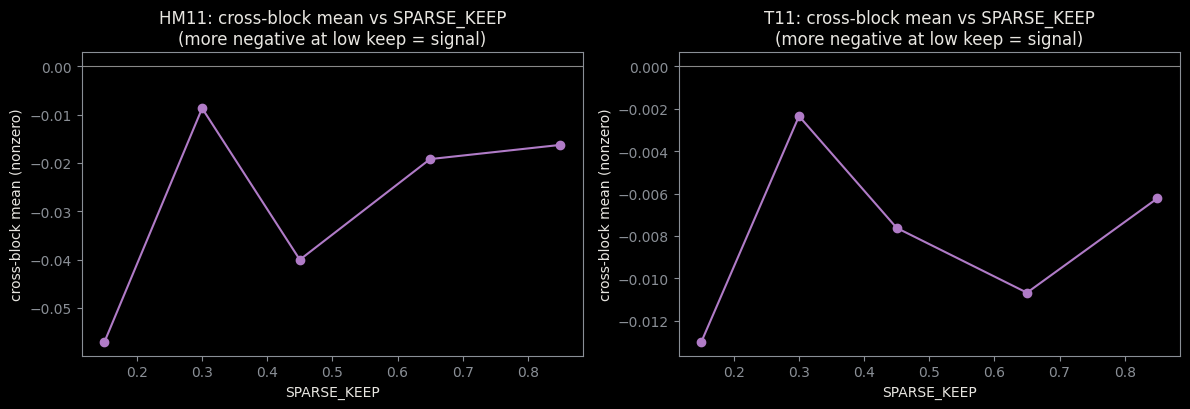


saved signed_signal_permutation.csv, signed_signal_sweep.csv, signed_signal_check.png


In [42]:
# ================================================================================
# SIGNED SIGNAL CHECK — is the negative fibrotic->tumour cross-block signal or noise?
# Needs (already in your notebook): data, train_mode, get_loader, OUTDIR, np, pd, plt
# One seed. (1) permutation null + (2) SPARSE_KEEP sweep, per section.
# ================================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def _cross_mean(G, fib, tum):
    return float(G[np.ix_(fib, tum)].mean())

def _perm_test(G, fib, tum, n_perm=2000, seed=0):
    rs = np.random.RandomState(seed); n = len(G)
    real = _cross_mean(G, fib, tum); nf, nt = len(fib), len(tum)
    null = np.empty(n_perm)
    for k in range(n_perm):
        perm = rs.permutation(n)
        null[k] = G[np.ix_(perm[:nf], perm[nf:nf+nt])].mean()
    p = float((null <= real).mean())                 # one-sided: more negative than chance
    z = float((real - null.mean()) / (null.std() + 1e-12))
    return real, float(null.mean()), z, p

KEEPS = [0.15, 0.30, 0.45, 0.65, 0.85]
rows, sweep_rows = [], []
fig, axes = plt.subplots(1, len(data), figsize=(6*len(data), 4.2), squeeze=False)

for ax, (nm, d) in zip(axes[0], data.items()):
    fib, tum = d["fib_genes"], d["tum_genes"]
    mdl = train_mode(get_loader(d["tmp"]), d["n"], "signed")          # signed coupling, one seed
    G = mdl.conv1.lin.weight.detach().cpu().numpy(); G = (G + G.T) / 2

    real, nullm, z, p = _perm_test(G, fib, tum, seed=SEED if "SEED" in globals() else 0)
    rows.append(dict(section=nm, cross_mean_real=round(real, 5), null_mean=round(nullm, 5),
                     z=round(z, 2), perm_p=p, verdict="signal" if p < 0.05 else "noise-consistent"))
    print(f"[{nm}] cross-block real={real:+.5f}  null={nullm:+.5f}  z={z:+.2f}  "
          f"perm p={p:.4f}  -> {'SIGNAL' if p<0.05 else 'consistent with noise'}")

    off = ~np.eye(len(G), dtype=bool); means = []
    for keep in KEEPS:
        tau = np.quantile(np.abs(G[off]), 1 - keep)
        Gs = np.where(np.abs(G) >= tau, G, 0.0)
        cb = Gs[np.ix_(fib, tum)]; nz = cb != 0
        m = float(cb[nz].mean()) if nz.any() else 0.0
        means.append(m)
        sweep_rows.append(dict(section=nm, keep=keep, cross_density=round(float(nz.mean()), 3),
                               cross_mean_nonzero=round(m, 5)))
    ax.plot(KEEPS, means, "o-", color="#B07BC7"); ax.axhline(0, color="#888", lw=.8)
    ax.set_title(f"{nm}: cross-block mean vs SPARSE_KEEP\n(more negative at low keep = signal)")
    ax.set_xlabel("SPARSE_KEEP"); ax.set_ylabel("cross-block mean (nonzero)")

plt.tight_layout(); plt.savefig(f"{OUTDIR}/signed_signal_check.png", dpi=140); plt.show()
pd.DataFrame(rows).to_csv(f"{OUTDIR}/signed_signal_permutation.csv", index=False)
pd.DataFrame(sweep_rows).to_csv(f"{OUTDIR}/signed_signal_sweep.csv", index=False)
print("\nsaved signed_signal_permutation.csv, signed_signal_sweep.csv, signed_signal_check.png")

## What this notebook establishes, read honestly

The setup trains a sparse signed coupling on both matched sections, and the experiments show, on the
locked model, that removing the fibrotic niche relieves tumour suppression in a dose-dependent,
reproducible direction — stronger from stroma to tumour than the reverse, and cooperative between
niches. The mechanics hold up: spherical normalization is lossless at about 0.9985, the knockout
registers at the source, and sign recovery on a synthetic ground truth passes strongly.

The claims the validation doesn't support yet are just as important to say out loud. The signed cross
block is consistently negative but doesn't beat a permutation null, with a permutation p near 0.30 on
HM11 and the same result independently at keep 0.15. The propagation is global rather than local. The
random niche control turned out to be contaminated, since several control niches are themselves tumour
niches, and the effect doesn't depend on the spatial graph, so it reads as mean-field. Across seeds the
direction holds while the significance wobbles.

The most likely single cause behind the non-significance and the loss of locality is spot-level mixing —
a Visium spot averages several cells before any spot-to-spot comparison happens. If the goal is to
certify significance and recover locality, the natural next step is a single-cell or subcellular readout
like Xenium, together with a random niche control rebuilt from confirmed normal niches only. Framed this
way, what I have is a directionally consistent, mechanically validated suppressive stroma-to-tumour
coupling — and I'm being upfront about the significance and locality that the current spot-level data
can't yet deliver.